## 1. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define month name mapping globally for use across cells
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

## 2. Data Loading

In [ ]:
# Load the Excel file
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/WalshCapstone/Aggregated_DataSet.xlsx'

# Install openpyxl if not already installed
!pip install openpyxl

# Get all sheet names
xl = pd.ExcelFile(file_path)
print("Available sheets:", xl.sheet_names)

Mounted at /content/drive
Available sheets: ['Trade_23_24', 'Trade_24_25', 'Trade_25_26', 'Consumption_23_24', 'Consumption_24_25', 'Consumption_25_26', 'GPR_Index', 'LPG_Price']


### 2.1 Load Trade Data (FY 2023-24)

In [ ]:
# Load trade data for each fiscal year
trade_23_24 = pd.read_excel(file_path, sheet_name='Trade_23_24', skiprows=8)
trade_24_25 = pd.read_excel(file_path, sheet_name='Trade_24_25', skiprows=8)
trade_25_26 = pd.read_excel(file_path, sheet_name='Trade_25_26', skiprows=8)

print("Trade 2023-24:", trade_23_24.head())
print("Trade 2023-24 shape:", trade_23_24.shape)
print("Trade 2024-25 shape:", trade_24_25.shape)
print("Trade 2025-26 shape:", trade_25_26.shape)

Trade 2023-24:   IMPORT/EXPORT         APRIL           MAY          JUNE          JULY  \
0       IMPORT^           NaN           NaN           NaN           NaN   
1     CRUDE OIL  19996.877330  20705.224409  19879.169661  19507.576904   
2      PRODUCTS           NaN           NaN           NaN           NaN   
3           LPG   1004.249689   1448.883918   1320.245640   1365.608286   
4            MS      0.003211      0.004736    145.885544      0.000000   

         AUGUST     SEPTEMBER       OCTOBER      NOVEMBER      DECEMBER  \
0           NaN           NaN           NaN           NaN           NaN   
1  19090.547154  17502.259847  18729.100482  18593.105322  19683.287085   
2           NaN           NaN           NaN           NaN           NaN   
3   1570.286139   1619.505865   1915.601373   1721.482959   1564.599827   
4    149.297587    151.146637    199.776944     71.282899      0.000000   

        JANUARY      FEBRUARY         MARCH          TOTAL  
0           NaN       

### 2.2 Load Consumption Data

In [ ]:
# Load consumption data without header, so the cleaning function can identify it internally
cons_23_24 = pd.read_excel(file_path, sheet_name='Consumption_23_24', header=None)
cons_24_25 = pd.read_excel(file_path, sheet_name='Consumption_24_25', header=None)
cons_25_26 = pd.read_excel(file_path, sheet_name='Consumption_25_26', header=None)

print("Consumption 2023-24 shape (raw):", cons_23_24.shape)
print("Consumption 2024-25 shape (raw):", cons_24_25.shape)
print("Consumption 25-26 shape (raw):", cons_25_26.shape)

Consumption 2023-24 shape (raw): (25, 14)
Consumption 2024-25 shape (raw): (30, 14)
Consumption 25-26 shape (raw): (26, 14)


### 2.3 Load GPR Index

In [ ]:
# Load GPR data
gpr_data = pd.read_excel(file_path, sheet_name='GPR_Index')
print("GPR data shape:", gpr_data.shape)
print("GPR columns:", gpr_data.columns.tolist()[:10])

GPR data shape: (39, 115)
GPR columns: ['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH']


### 2.4 Load LPG Price Data

In [ ]:
# Load LPG price data
lpg_price = pd.read_excel(file_path, sheet_name='LPG_Price')
print("LPG Price data shape:", lpg_price.shape)
print("LPG Price columns:", lpg_price.columns.tolist())

LPG Price data shape: (122, 5)
LPG Price columns: ['Previous Price of Nonsubsidised 14.2 Kg IndaneGas', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


## 3. Data Cleaning - Trade Data

In [ ]:
def clean_trade_data(df, year_label):
    """
    Clean trade data by extracting relevant columns and reshaping.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df_processed = df.copy()
    # The first column is the product/category name, rest are months and TOTAL
    df_processed.columns = ['Category'] + months + ['TOTAL']

    # Initialize series for LPG import and export data for current year
    lpg_import_qty_series = pd.Series([np.nan]*12, index=months)
    lpg_export_qty_series = pd.Series([np.nan]*12, index=months)

    # Find the row indices for 'IMPORT^' and 'EXPORT^'
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index

    # Extract Import quantities
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        # Determine the end of the import section: either the start of export section or end of dataframe
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)

        # Search for 'LPG' within the identified import section
        lpg_import_data = df_processed.loc[import_start_row:import_end_row-1] # Slice up to, but not including, export header
        lpg_import_row = lpg_import_data[lpg_import_data['Category'].str.strip() == 'LPG']

        if not lpg_import_row.empty:
            lpg_import_qty_series = lpg_import_row.iloc[0][months] # Extract monthly values

    # Extract Export quantities
    if not export_header_idx.empty:
        export_start_row = export_header_idx[0]

        # Search for 'LPG' within the identified export section (from export header to end)
        lpg_export_data = df_processed.loc[export_start_row:]
        lpg_export_row = lpg_export_data[lpg_export_data['Category'].str.strip() == 'LPG']

        if not lpg_export_row.empty:
            lpg_export_qty_series = lpg_export_row.iloc[0][months] # Extract monthly values

    # Create DataFrame for the current fiscal year
    result = pd.DataFrame({
        'Month': months,
        'LPG_Import_Qty': lpg_import_qty_series.values,
        'LPG_Export_Qty': lpg_export_qty_series.values,
        'Fiscal_Year': year_label
    })

    return result

# Clean trade data for each year
trade_23_24_clean = clean_trade_data(trade_23_24, '2023-24')
trade_24_25_clean = clean_trade_data(trade_24_25, '2024-25')
trade_25_26_clean = clean_trade_data(trade_25_26, '2025-26')

# Combine all trade data
trade_all = pd.concat([trade_23_24_clean, trade_24_25_clean, trade_25_26_clean], ignore_index=True)
print("Combined trade data shape:", trade_all.shape)
trade_all.head(40)

Combined trade data shape: (36, 4)


,Month,LPG_Import_Qty,LPG_Export_Qty,Fiscal_Year
0,APR,1004.249689,40.23,2023-24
1,MAY,1448.883918,45.916,2023-24
2,JUN,1320.24564,41.224,2023-24
3,JUL,1365.608286,41.138,2023-24
4,AUG,1570.286139,46.627,2023-24
5,SEP,1619.505865,39.502,2023-24
6,OCT,1915.601373,43.369,2023-24
7,NOV,1721.482959,44.216,2023-24
8,DEC,1564.599827,45.309,2023-24
9,JAN,1644.523514,45.003,2023-24


## 4. Data Cleaning - Consumption Data

In [ ]:
def clean_consumption_data(df_raw, year_label):
    """
    Clean consumption data and extract LPG consumption.
    Handles varying header rows by identifying the row containing 'PRODUCTS' and a month name.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df = df_raw.copy()

    # Find the header row: it contains 'PRODUCTS' and 'APR' (or another month)
    header_row_idx = -1
    for idx, row in df.iterrows():
        # Convert row values to string and upper case for robust matching
        row_values = row.astype(str).str.upper().tolist()
        # Check if 'PRODUCTS' is in the row and at least one month name is present
        if 'PRODUCTS' in row_values and any(m in row_values for m in months):
            header_row_idx = idx
            break

    if header_row_idx == -1:
        # If no header row found, return DataFrame with NaN for LPG_Consumption for this year
        return pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})

    # Set the identified row as the new header
    df.columns = df.iloc[header_row_idx]
    # Drop rows before and including the header row
    df = df[header_row_idx+1:].reset_index(drop=True)

    # Clean column names (remove leading/trailing spaces, convert to upper case for consistency)
    df.columns = [col.strip().upper() if isinstance(col, str) else col for col in df.columns]

    # Filter out rows where 'PRODUCTS' is NaN, empty, or not a string (e.g., numbers)
    df_clean = df.dropna(subset=['PRODUCTS'])
    df_clean = df_clean[df_clean['PRODUCTS'].astype(str).str.strip() != '']

    # Find the row where the 'PRODUCTS' column contains 'LPG'
    lpg_row = df_clean[df_clean['PRODUCTS'].astype(str).str.strip().str.upper() == 'LPG']

    if not lpg_row.empty:
        lpg_values = []
        for month in months:
            # Check if the month column exists in the cleaned DataFrame
            if month in df_clean.columns:
                val = lpg_row.iloc[0][month]
                # Convert to numeric, coerce errors to NaN
                lpg_values.append(pd.to_numeric(val, errors='coerce'))
            else:
                lpg_values.append(np.nan)

        result = pd.DataFrame({
            'Month': months,
            'LPG_Consumption': lpg_values,
            'Fiscal_Year': year_label
        })
    else:
        # If no LPG row is found, create a DataFrame with NaN values for LPG_Consumption
        result = pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})

    return result

# Clean consumption data
cons_23_24_clean = clean_consumption_data(cons_23_24, '2023-24')
cons_24_25_clean = clean_consumption_data(cons_24_25, '2024-25')
cons_25_26_clean = clean_consumption_data(cons_25_26, '2025-26')

print("Consumption 2023-24 shape (clean):", cons_23_24_clean.head())
print("Consumption 2024-25 shape (clean):", cons_24_25_clean.head())
print("Consumption 25-26 shape (clean):", cons_25_26_clean.head())

# Combine
cons_all = pd.concat([cons_23_24_clean, cons_24_25_clean, cons_25_26_clean], ignore_index=True)
print("Combined consumption data shape:", cons_all.shape)
cons_all.head(36)

Consumption 2023-24 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR          2154.30     2023-24
1   MAY          2347.11     2023-24
2   JUN          2232.86     2023-24
3   JUL          2389.57     2023-24
4   AUG          2460.41     2023-24
Consumption 2024-25 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR             2373     2024-25
1   MAY             2410     2024-25
2   JUN             2320     2024-25
3   JUL             2649     2024-25
4   AUG             2664     2024-25
Consumption 25-26 shape (clean):   Month  LPG_Consumption Fiscal_Year
0   APR      2544.531448     2025-26
1   MAY      2681.803172     2025-26
2   JUN      2554.162132     2025-26
3   JUL      2809.639670     2025-26
4   AUG      2833.093852     2025-26
Combined consumption data shape: (36, 3)


,Month,LPG_Consumption,Fiscal_Year
0,APR,2154.300000,2023-24
1,MAY,2347.110000,2023-24
2,JUN,2232.860000,2023-24
3,JUL,2389.570000,2023-24
4,AUG,2460.410000,2023-24
5,SEP,2551.110000,2023-24
6,OCT,2495.720000,2023-24
7,NOV,2486.520000,2023-24
8,DEC,2628.250000,2023-24
9,JAN,2697.610000,2023-24


## 5. Data Cleaning - GPR Index

In [ ]:
# GPR data has a 'month' column - convert to datetime and extract date components
gpr_clean = gpr_data.copy()
gpr_clean['date'] = pd.to_datetime(gpr_clean['month'])
gpr_clean['year'] = gpr_clean['date'].dt.year
gpr_clean['month_num'] = gpr_clean['date'].dt.month

# Adjust fiscal year logic (April = start of fiscal year)
def get_fiscal_year(date_obj):
    if date_obj.month >= 4:
        return f"{date_obj.year}-{str(date_obj.year+1)[-2:]}"
    else:
        return f"{date_obj.year-1}-{str(date_obj.year)[-2:]}"

gpr_clean['Fiscal_Year'] = gpr_clean['date'].apply(get_fiscal_year)
gpr_clean['Month_Name'] = gpr_clean['month_num'].map(month_names)

# Select relevant columns, excluding 'year', 'date', and 'month_num'
gpr_filtered = gpr_clean[['Month_Name', 'Fiscal_Year', 'GPR']].copy()

# Filter out 2022-23 fiscal year
gpr_filtered = gpr_filtered[gpr_filtered['Fiscal_Year'] != '2022-23']

print("GPR data after cleaning:")
print(f"Date range: {gpr_clean['date'].min()} to {gpr_clean['date'].max()}") # Use gpr_clean for full date range display
print(f"Fiscal years available: {gpr_filtered['Fiscal_Year'].unique()}")

gpr_filtered.head(36)

GPR data after cleaning:
Date range: 2023-01-01 00:00:00 to 2026-03-01 00:00:00
Fiscal years available: ['2023-24' '2024-25' '2025-26']


,Month_Name,Fiscal_Year,GPR
3,APR,2023-24,106.809654
4,MAY,2023-24,108.467682
5,JUN,2023-24,110.528946
6,JUL,2023-24,107.448784
7,AUG,2023-24,101.141182
8,SEP,2023-24,98.634811
9,OCT,2023-24,197.887009
10,NOV,2023-24,156.696136
11,DEC,2023-24,142.279465
12,JAN,2023-24,160.373657


## 6. Data Cleaning - LPG Price

In [ ]:
# Clean LPG price data - focus on Delhi price as representative
price_clean = lpg_price.copy()
price_clean.columns = ['Date', 'Delhi', 'Kolkata', 'Mumbai', 'Chennai']

# Convert date strings to datetime
def parse_price_date(date_str):
    if pd.isna(date_str):
        return np.nan
    try:
        # Handle formats like "April 8, 2025" and "August 1, 2024"
        return pd.to_datetime(date_str, format='%B %d, %Y')
    except:
        try:
            return pd.to_datetime(date_str, format='%B %d, %Y', errors='coerce')
        except:
            return np.nan

price_clean['date'] = price_clean['Date'].apply(parse_price_date)

# Remove rows with invalid dates
price_clean = price_clean.dropna(subset=['date'])

# Sort by date
price_clean = price_clean.sort_values('date').reset_index(drop=True)

# Convert price columns to numeric, coercing errors (e.g., 'No Change' to NaN)
price_clean['Delhi'] = pd.to_numeric(price_clean['Delhi'], errors='coerce')
price_clean['Kolkata'] = pd.to_numeric(price_clean['Kolkata'], errors='coerce')
price_clean['Mumbai'] = pd.to_numeric(price_clean['Mumbai'], errors='coerce')
price_clean['Chennai'] = pd.to_numeric(price_clean['Chennai'], errors='coerce')

# Create fiscal year and month name columns
price_clean['year'] = price_clean['date'].dt.year
price_clean['month'] = price_clean['date'].dt.month
price_clean['Fiscal_Year'] = price_clean['date'].apply(get_fiscal_year)
price_clean['Month_Name'] = price_clean['month'].map(month_names)

# Define the target fiscal years and month order
fiscal_years_to_process = ['2023-24', '2024-25', '2025-26']
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

# Filter price_clean to include only the relevant fiscal years
price_clean_filtered = price_clean[price_clean['Fiscal_Year'].isin(fiscal_years_to_process)].copy()

# Create a complete timeline for the target fiscal years
full_timeline_data = []
for fy in fiscal_years_to_process:
    for month_name in months_order:
        full_timeline_data.append({
            'Fiscal_Year': fy,
            'Month_Name': month_name
        })
full_timeline_df = pd.DataFrame(full_timeline_data)

# Calculate monthly average prices from the filtered price_clean data
monthly_avg_prices = price_clean_filtered.groupby(['Fiscal_Year', 'Month_Name'])['Delhi'].mean().reset_index()
monthly_avg_prices.rename(columns={'Delhi': 'LPG_Price_Delhi'}, inplace=True)

# Merge monthly average prices into the full timeline. This will have NaNs for missing months.
price_delhi = full_timeline_df.merge(monthly_avg_prices,
                                   on=['Fiscal_Year', 'Month_Name'],
                                   how='left')

# Calculate yearly average prices from the monthly_avg_prices (which already contains existing data)
yearly_avg_prices_fill = monthly_avg_prices.groupby('Fiscal_Year')['LPG_Price_Delhi'].mean().reset_index()
yearly_avg_prices_fill.rename(columns={'LPG_Price_Delhi': 'LPG_Price_Delhi_Avg'}, inplace=True)

# Merge yearly averages for filling into price_delhi
price_delhi = price_delhi.merge(yearly_avg_prices_fill, on=['Fiscal_Year'], how='left')

# Fill NaN values in 'LPG_Price_Delhi' with the yearly average
price_delhi['LPG_Price_Delhi'] = price_delhi['LPG_Price_Delhi'].fillna(price_delhi['LPG_Price_Delhi_Avg'])

# Drop the temporary average column
price_delhi.drop(columns=['LPG_Price_Delhi_Avg'], inplace=True)

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
price_delhi['LPG_Price_Delhi'] = pd.to_numeric(price_delhi['LPG_Price_Delhi'], errors='coerce')


print("LPG price data range (original price_clean):", price_clean['date'].min(), "to", price_clean['date'].max())
print(f"Fiscal years available in price_delhi: {price_delhi['Fiscal_Year'].unique()}")
print("Price_delhi shape:", price_delhi.shape)
price_delhi.head(40)

LPG price data range (original price_clean): 2013-12-11 00:00:00 to 2025-04-08 00:00:00
Fiscal years available in price_delhi: ['2023-24' '2024-25' '2025-26']
Price_delhi shape: (36, 3)


,Fiscal_Year,Month_Name,LPG_Price_Delhi
0,2023-24,APR,853.0
1,2023-24,MAY,853.0
2,2023-24,JUN,853.0
3,2023-24,JUL,853.0
4,2023-24,AUG,903.0
5,2023-24,SEP,853.0
6,2023-24,OCT,853.0
7,2023-24,NOV,853.0
8,2023-24,DEC,853.0
9,2023-24,JAN,853.0


In [ ]:
import pandas as pd
import numpy as np

# Ensure month_names is available for the create_date function
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

# Create a unified timeline (April 2023 - March 2026)
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
fiscal_years = ['2023-24', '2024-25', '2025-26']

# Create master dataframe with all months
master_data = []
for fy in fiscal_years:
    for month in months_order:
        master_data.append({
            'Fiscal_Year': fy,
            'Month': month
        })

master_df = pd.DataFrame(master_data)

# Fix dates properly
def create_date(fy, month):
    year = int(fy[:4])
    # Ensure month_names is accessible globally
    month_num = list(month_names.keys())[list(month_names.values()).index(month)]
    if month_num <= 3:
        year += 1
    return pd.Timestamp(year=year, month=month_num, day=1)

master_df['Date'] = master_df.apply(lambda x: create_date(x['Fiscal_Year'], x['Month']), axis=1)

# Merge trade data
master_df = master_df.merge(trade_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge consumption data
master_df = master_df.merge(cons_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge GPR data (need to match month and year)
# Use gpr_clean (which has the 'date' column) and filter by fiscal_years
gpr_for_merge = gpr_clean[gpr_clean['Fiscal_Year'].isin(fiscal_years)][['date', 'GPR', 'Fiscal_Year', 'Month_Name']].copy()
gpr_for_merge = gpr_for_merge.rename(columns={'date': 'GPR_Date', 'Month_Name': 'Month'})
master_df = master_df.merge(gpr_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Merge price data
price_for_merge = price_delhi[['LPG_Price_Delhi', 'Fiscal_Year', 'Month_Name']].copy()
price_for_merge = price_for_merge.rename(columns={'Month_Name': 'Month'})
# For each fiscal year-month, get the price (take first or last price in month)
price_for_merge = price_for_merge.drop_duplicates(subset=['Fiscal_Year', 'Month'], keep='first')
master_df = master_df.merge(price_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
master_df['LPG_Price_Delhi'] = pd.to_numeric(master_df['LPG_Price_Delhi'], errors='coerce')

# Sort by date
master_df = master_df.sort_values('Date').reset_index(drop=True)


print("===============================================================================")

# Verify data completeness
print("Master dataset shape:", master_df.shape)
print("\nData Completeness Check:")
for col in master_df.columns:
    if col not in ['Fiscal_Year', 'Month', 'Date']:
        non_null_pct = master_df[col].notna().mean() * 100
        print(f"  {col}: {non_null_pct:.1f}% complete")

Master dataset shape: (36, 9)

Data Completeness Check:
  LPG_Import_Qty: 97.2% complete
  LPG_Export_Qty: 97.2% complete
  LPG_Consumption: 100.0% complete
  GPR_Date: 100.0% complete
  GPR: 100.0% complete
  LPG_Price_Delhi: 100.0% complete


**SAMPLE MASTER DATA**

In [ ]:
master_df.head(20)

,Fiscal_Year,Month,Date,LPG_Import_Qty,LPG_Export_Qty,LPG_Consumption,GPR_Date,GPR,LPG_Price_Delhi
0,2023-24,APR,2023-04-01,1004.249689,40.23,2154.30,2023-04-01,106.809654,853.0
1,2023-24,MAY,2023-05-01,1448.883918,45.916,2347.11,2023-05-01,108.467682,853.0
2,2023-24,JUN,2023-06-01,1320.24564,41.224,2232.86,2023-06-01,110.528946,853.0
3,2023-24,JUL,2023-07-01,1365.608286,41.138,2389.57,2023-07-01,107.448784,853.0
4,2023-24,AUG,2023-08-01,1570.286139,46.627,2460.41,2023-08-01,101.141182,903.0
5,2023-24,SEP,2023-09-01,1619.505865,39.502,2551.11,2023-09-01,98.634811,853.0
6,2023-24,OCT,2023-10-01,1915.601373,43.369,2495.72,2023-10-01,197.887009,853.0
7,2023-24,NOV,2023-11-01,1721.482959,44.216,2486.52,2023-11-01,156.696136,853.0
8,2023-24,DEC,2023-12-01,1564.599827,45.309,2628.25,2023-12-01,142.279465,853.0
9,2023-24,JAN,2024-01-01,1644.523514,45.003,2697.61,2024-01-01,160.373657,853.0


### Feature Engineering with Lag related columns


In [ ]:
import pandas as pd
import numpy as np

# Make a copy of master_df_ts (which already has Date as index and correct Year/Month columns)
features_df = master_df.copy()

# 1. Add lagged features

# GPR Index (t-1, t-2, t-3)
features_df['gpr_index_lag1'] = features_df['GPR'].shift(1)
features_df['gpr_index_lag2'] = features_df['GPR'].shift(2)
features_df['gpr_index_lag3'] = features_df['GPR'].shift(3)

# LPG Price Delhi (t-1)
# The current LPG_Price_Delhi column represents 't'
features_df['lpg_price_delhi_lag1'] = features_df['LPG_Price_Delhi'].shift(1)

# LPG Import Quantity (t-1, t-2)
# The current LPG_Import_Qty column represents 't'
features_df['lpg_import_qty_lag1'] = features_df['LPG_Import_Qty'].shift(1)
features_df['lpg_import_qty_lag2'] = features_df['LPG_Import_Qty'].shift(2)

# LPG Consumption (t-1)
features_df['lpg_consumption_lag1'] = features_df['LPG_Consumption'].shift(1)

# 2. Add engineered features

# Net Import Ratio (import/consumption)
features_df['net_import_ratio'] = features_df['LPG_Import_Qty'] / features_df['LPG_Consumption']

# Price Change PCT (MoM %) for LPG_Price_Delhi
features_df['price_change_pct'] = features_df['LPG_Price_Delhi'].pct_change() * 100

# Month Sine and Cosine for seasonality
month_num = features_df['Date'].dt.month
features_df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
features_df['month_cos'] = np.cos(2 * np.pi * month_num / 12)

# Rolling Price Volatility (3m) - rolling std for LPG_Price_Delhi
features_df['rolling_price_volatility_3m'] = features_df['LPG_Price_Delhi'].rolling(window=3).std()

# 3. Add crude_import_qty (Original)

# Re-define the helper function to extract crude oil data from raw trade dataframes
def extract_crude_import_data(df, year_label):
    """
    Extract crude oil import data from a raw trade DataFrame.
    """
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']

    df_processed = df.copy()
    # Assume the first column is 'Category' and the rest are months + 'TOTAL'
    df_processed.columns = ['Category'] + months + ['TOTAL']

    crude_import_qty_series = pd.Series([np.nan]*12, index=months)

    # Find the row indices for 'IMPORT^' and 'EXPORT^'
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index

    # Extract Import quantities
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        # Determine the end of the import section: either the start of export section or end of dataframe
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)

        # Search for 'CRUDE OIL' within the identified import section
        crude_import_data = df_processed.loc[import_start_row:import_end_row-1] # Slice up to, but not including, export header
        crude_import_row = crude_import_data[crude_import_data['Category'].str.strip() == 'CRUDE OIL']

        if not crude_import_row.empty:
            crude_import_qty_series = crude_import_row.iloc[0][months] # Extract monthly values

    result = pd.DataFrame({
        'Month': months,
        'Crude_Import_Qty': crude_import_qty_series.values,
        'Fiscal_Year': year_label
    })
    return result

# Ensure trade_23_24, trade_24_25, trade_25_26 are available in the environment
# (They were loaded in cell 4135e344 and should be in the kernel state)

# Extract crude import data for each year
crude_23_24_clean = extract_crude_import_data(trade_23_24, '2023-24')
crude_24_25_clean = extract_crude_import_data(trade_24_25, '2024-25')
crude_25_26_clean = extract_crude_import_data(trade_25_26, '2025-26')

# Combine all crude data
crude_all = pd.concat([crude_23_24_clean, crude_24_25_clean, crude_25_26_clean], ignore_index=True)

# Convert Crude_Import_Qty to numeric, coercing errors
crude_all['Crude_Import_Qty'] = pd.to_numeric(crude_all['Crude_Import_Qty'], errors='coerce')

# The 'Fiscal_Year' column is already present in crude_all from extract_crude_import_data,
# and it contains the fiscal year strings (e.g., '2023-24').
# There's no need to rename it to 'Year' if features_df uses 'Fiscal_Year'.
# So, the following line is removed: crude_all.rename(columns={'Fiscal_Year': 'Year'}, inplace=True)

# Merge crude_all into features_df
# The merge should happen on 'Fiscal_Year' and 'Month' as features_df also has 'Fiscal_Year'
features_df = features_df.merge(crude_all, on=['Fiscal_Year', 'Month'], how='left')

# Display the first few rows and info of the new features_df
print("New features_df head:")
print(features_df.head())
print("\nNew features_df info:")
features_df.info()

New features_df head:
  Fiscal_Year Month       Date LPG_Import_Qty LPG_Export_Qty  LPG_Consumption  \
0     2023-24   APR 2023-04-01    1004.249689          40.23          2154.30   
1     2023-24   MAY 2023-05-01    1448.883918         45.916          2347.11   
2     2023-24   JUN 2023-06-01     1320.24564         41.224          2232.86   
3     2023-24   JUL 2023-07-01    1365.608286         41.138          2389.57   
4     2023-24   AUG 2023-08-01    1570.286139         46.627          2460.41   

    GPR_Date         GPR  LPG_Price_Delhi  gpr_index_lag1  ...  \
0 2023-04-01  106.809654            853.0             NaN  ...   
1 2023-05-01  108.467682            853.0      106.809654  ...   
2 2023-06-01  110.528946            853.0      108.467682  ...   
3 2023-07-01  107.448784            853.0      110.528946  ...   
4 2023-08-01  101.141182            903.0      107.448784  ...   

   lpg_price_delhi_lag1  lpg_import_qty_lag1  lpg_import_qty_lag2  \
0                   NaN  

In [ ]:
# Add interaction term between LPG Price and GPR
features_df['LPG_Price_Delhi_GPR_Interaction'] = features_df['LPG_Price_Delhi'] * features_df['GPR']

print("Added 'LPG_Price_Delhi_GPR_Interaction' to features_df.")
print(features_df[['LPG_Price_Delhi', 'GPR', 'LPG_Price_Delhi_GPR_Interaction']].head())

Added 'LPG_Price_Delhi_GPR_Interaction' to features_df.
   LPG_Price_Delhi         GPR  LPG_Price_Delhi_GPR_Interaction
0            853.0  106.809654                     91108.635063
1            853.0  108.467682                     92522.932648
2            853.0  110.528946                     94281.190872
3            853.0  107.448784                     91653.812645
4            903.0  101.141182                     91330.487297


In [ ]:
print("### 8.1 Overview of Engineered Features")
print("Displaying the first few rows of `features_df` to show the newly added features:")
display(features_df.head())

print("\nKey Engineered Features:")
print("- **Lagged Features**: GPR (t-1, t-2, t-3), LPG Price Delhi (t-1), LPG Import Quantity (t-1, t-2) - help capture temporal dependencies.")
print("- **Net Import Ratio**: `LPG_Import_Qty / LPG_Consumption` - indicates reliance on imports relative to demand.")
print("- **Price Change PCT**: `LPG_Price_Delhi` Month-over-Month percentage change - measures price volatility.")
print("- **Month Sine/Cosine**: `month_sin`, `month_cos` - captures seasonality in a continuous form.")
print("- **Rolling Price Volatility (3m)**: Standard deviation of `LPG_Price_Delhi` over a 3-month window - another measure of price stability.")
print("- **Crude Import Quantity**: Directly imported crude oil quantity - a potential upstream indicator for energy supply and pricing.")

### 8.1 Overview of Engineered Features
Displaying the first few rows of `features_df` to show the newly added features:


,Fiscal_Year,Month,Date,LPG_Import_Qty,LPG_Export_Qty,LPG_Consumption,GPR_Date,GPR,LPG_Price_Delhi,gpr_index_lag1,...,lpg_import_qty_lag1,lpg_import_qty_lag2,lpg_consumption_lag1,net_import_ratio,price_change_pct,month_sin,month_cos,rolling_price_volatility_3m,Crude_Import_Qty,LPG_Price_Delhi_GPR_Interaction
0,2023-24,APR,2023-04-01,1004.249689,40.23,2154.30,2023-04-01,106.809654,853.0,NaN,...,None,None,NaN,0.466161,NaN,8.660254e-01,-0.500000,NaN,19996.877330,91108.635063
1,2023-24,MAY,2023-05-01,1448.883918,45.916,2347.11,2023-05-01,108.467682,853.0,106.809654,...,1004.249689,None,2154.30,0.617306,0.000000,5.000000e-01,-0.866025,NaN,20705.224409,92522.932648
2,2023-24,JUN,2023-06-01,1320.24564,41.224,2232.86,2023-06-01,110.528946,853.0,108.467682,...,1448.883918,1004.249689,2347.11,0.59128,0.000000,1.224647e-16,-1.000000,0.000000,19879.169661,94281.190872
3,2023-24,JUL,2023-07-01,1365.608286,41.138,2389.57,2023-07-01,107.448784,853.0,110.528946,...,1320.24564,1448.883918,2232.86,0.571487,0.000000,-5.000000e-01,-0.866025,0.000000,19507.576904,91653.812645
4,2023-24,AUG,2023-08-01,1570.286139,46.627,2460.41,2023-08-01,101.141182,903.0,107.448784,...,1365.608286,1320.24564,2389.57,0.638221,5.861665,-8.660254e-01,-0.500000,28.867513,19090.547154,91330.487297



Key Engineered Features:
- **Lagged Features**: GPR (t-1, t-2, t-3), LPG Price Delhi (t-1), LPG Import Quantity (t-1, t-2) - help capture temporal dependencies.
- **Net Import Ratio**: `LPG_Import_Qty / LPG_Consumption` - indicates reliance on imports relative to demand.
- **Price Change PCT**: `LPG_Price_Delhi` Month-over-Month percentage change - measures price volatility.
- **Month Sine/Cosine**: `month_sin`, `month_cos` - captures seasonality in a continuous form.
- **Rolling Price Volatility (3m)**: Standard deviation of `LPG_Price_Delhi` over a 3-month window - another measure of price stability.
- **Crude Import Quantity**: Directly imported crude oil quantity - a potential upstream indicator for energy supply and pricing.


## RQ2 (Policy: Price Elasticity & Subsidy Design)
Research Question: How does the non-linear price elasticity of LPG demand vary across high and low geopolitical risk regimes, and what are the implications for subsidy targeting under the PMUY scheme?


### Null and Alternate Hypotheses

**Research Question:** How does the non-linear price elasticity of LPG demand vary across high and low geopolitical risk regimes, and what are the implications for subsidy targeting under the PMUY scheme?

**Null Hypothesis (H0):** The price elasticity of LPG demand does not significantly vary between low and high geopolitical risk regimes. In other words, the impact of LPG price changes on demand is similar regardless of the geopolitical risk level.

**Alternate Hypothesis (H1):** The price elasticity of LPG demand significantly varies between low and high geopolitical risk regimes. This implies that the impact of LPG price changes on demand is different when geopolitical risk is low compared to when it is high.

### Exploring Alternative Models: Bayesian Structural Time Series (BSTS)

Given the challenges with traditional supervised learning models on our small dataset, let's explore Bayesian Structural Time Series (BSTS). BSTS models are well-suited for time-series data, especially when the number of observations is limited. They decompose a time series into interpretable components like trend, seasonality, and regressor effects, and provide probabilistic forecasts with credible intervals, which is highly valuable for an early warning system.

### Why BSTS for Small Datasets?

1.  **Handles Uncertainty Naturally**: Bayesian methods provide full posterior distributions for parameters and predictions, allowing us to quantify uncertainty. This is crucial for small datasets where point estimates can be unreliable.
2.  **Decomposition**: They explicitly model underlying components (e.g., trend, seasonality), which can be stable even with sparse data, leading to more robust estimates.
3.  **Prior Information**: Bayesian models can incorporate prior beliefs about parameters, which is particularly useful when data is scarce, as it can help regularize the model and guide it towards more sensible solutions.
4.  **Flexible Structure**: BSTS allows for the inclusion of external regressors, providing a way to integrate our GPR index, LPG price, and import quantities into the forecasting framework.

In [ ]:
# Install cmdstanpy (if not already installed)
# cmdstanpy is often preferred for newer Stan projects due to its performance and flexibility.
# This might take a few minutes to install and compile CmdStan.
!pip install cmdstanpy

In [ ]:
# Install CmdStan itself
# This will download and compile the CmdStan toolkit, which cmdstanpy needs.
# This may take several minutes.
from cmdstanpy import install_cmdstan
install_cmdstan()

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.39.0
Download successful, file: /tmp/tmpnl5q5f6_
Extracting distribution
Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
Installed cmdstan-2.39.0
Test model compilation


True

### BSTS Model Setup: Data Preparation

In [ ]:
import pandas as pd
import numpy as np
# from cmdstanpy import CmdStanModel # Commented out for now, will be used in later steps

# --- 1. Define Target and Exogenous Variables for BSTS --- #

# Our target variable is LPG_Consumption
target_variable = 'LPG_Consumption'

# Define exogenous variables (regressors) for the BSTS model.
# These are features that are believed to influence LPG_Consumption.
# We will use GPR, LPG_Price_Delhi, LPG_Import_Qty, and Crude_Import_Qty,
# along with their lagged values for a richer model.

exog_variables = [
    'GPR', 'LPG_Price_Delhi', 'LPG_Import_Qty', 'Crude_Import_Qty',
    'lpg_consumption_lag1', # Lagged consumption for autoregressive component
    'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3',
    'lpg_import_qty_lag1', 'lpg_import_qty_lag2',
    'month_sin', 'month_cos',
    'LPG_Price_Delhi_GPR_Interaction' # NEW: Interaction term for regime-specific elasticity
]

# --- 2. Prepare Data for BSTS Model --- #

# We'll use the `features_df` which already contains all engineered features and growth rates.
# First, ensure the 'Date' index is properly set and sorted for time-series operations.
# (This was already done when creating `master_df_ts` / `features_df` but is re-applied here for robustness)

# Make a copy to avoid modifying the original features_df accidentally
model_df_bsts = features_df.copy()

# Drop rows with NaN values in target or exogenous variables. This is crucial for BSTS.
# Lagged features at the beginning of the series will have NaNs.
columns_for_bsts = [target_variable] + exog_variables
model_df_bsts = model_df_bsts[columns_for_bsts].dropna()

print("Prepared data for BSTS model:")
print(model_df_bsts.head())
print(f"\nShape of BSTS model data: {model_df_bsts.shape}")
print(f"Number of observations after dropping NaNs: {len(model_df_bsts)}")

Prepared data for BSTS model:
   LPG_Consumption         GPR  LPG_Price_Delhi LPG_Import_Qty  \
3          2389.57  107.448784            853.0    1365.608286   
4          2460.41  101.141182            903.0    1570.286139   
5          2551.11   98.634811            853.0    1619.505865   
6          2495.72  197.887009            853.0    1915.601373   
7          2486.52  156.696136            853.0    1721.482959   

   Crude_Import_Qty  lpg_consumption_lag1  gpr_index_lag1  gpr_index_lag2  \
3      19507.576904               2232.86      110.528946      108.467682   
4      19090.547154               2389.57      107.448784      110.528946   
5      17502.259847               2460.41      101.141182      107.448784   
6      18729.100482               2551.11       98.634811      101.141182   
7      18593.105322               2495.72      197.887009       98.634811   

   gpr_index_lag3 lpg_import_qty_lag1 lpg_import_qty_lag2  month_sin  \
3      106.809654          1320.24564 

### BSTS Model Setup: Train-Test Split

In [ ]:
# --- 3. Train-Test Split for BSTS --- #

# Given the small dataset, we'll try a 70/30 split, but keep in mind that with only 32 data points,
# any split will result in very small train/test sets.

split_ratio = 0.7 # 70% for training, 30% for testing
split_point = int(len(model_df_bsts) * split_ratio)

y_train_bsts = model_df_bsts[target_variable].iloc[:split_point]
X_train_bsts = model_df_bsts[exog_variables].iloc[:split_point]

y_test_bsts = model_df_bsts[target_variable].iloc[split_point:]
X_test_bsts = model_df_bsts[exog_variables].iloc[split_point:]

print(f"BSTS Training data points: {len(y_train_bsts)}")
print(f"BSTS Testing data points: {len(y_test_bsts)}")

# Also create full y and X for the model fitting, to be used if fitting the whole series
y_full_bsts = model_df_bsts[target_variable]
X_full_bsts = model_df_bsts[exog_variables]

print(f"\nFull BSTS data points: {len(y_full_bsts)}")

BSTS Training data points: 22
BSTS Testing data points: 10

Full BSTS data points: 32


### BSTS Model Implementation and Evaluation

In [ ]:
import pandas as pd
import numpy as np
import os
from cmdstanpy import CmdStanModel
from sklearn.metrics import r2_score, mean_squared_error

# Define path for the Stan model file
stan_file_path = "bsts_model_simplified.stan"

# Stan model code (Local Level Trend + Additive Seasonal + Regression)
stan_code_content = """
data {
  int<lower=0> N_train;              // Number of training observations
  int<lower=0> K;                    // Number of exogenous variables
  array[N_train] real y_train;        // Target variable for training
  matrix[N_train, K] X_train;        // Exogenous variables for training

  int<lower=0> N_predict;            // Number of observations to predict (test set size)
  matrix[N_predict, K] X_predict;    // Exogenous variables for prediction

  real y_initial_mean;               // Mean of initial y to set prior for initial level
  real y_initial_sd;                 // SD of initial y to set prior for initial level

  int<lower=1> period;              // Seasonal period (e.g., 12 for monthly)
}

parameters {
  real<lower=0> sigma_obs;          // Observation error standard deviation
  real<lower=0> sigma_level;        // Level error standard deviation
  real<lower=0> sigma_seasonal;     // Seasonal error standard deviation (new)
  vector[K] beta;                   // Regression coefficients
  array[N_train] real latent_level_train; // Latent level state for training data
  array[N_train] real latent_seasonal_train; // Latent seasonal state for training data (new)
}

model {
  // Priors
  sigma_obs ~ exponential(1);     // Weakly informative prior for observation noise
  sigma_level ~ exponential(1);   // Weakly informative prior for level noise
  sigma_seasonal ~ exponential(1); // Weakly informative prior for seasonal noise
  beta ~ normal(0, 5);            // Weakly informative prior for regression coefficients

  // Initial state for the latent level
  latent_level_train[1] ~ normal(y_initial_mean, y_initial_sd);

  // Random walk process for the latent level during training
  for (n in 2:N_train) {
    latent_level_train[n] ~ normal(latent_level_train[n-1], sigma_level);
  }

  // Priors for initial seasonal states (first 'period' values)
  for (i in 1:period) {
    latent_seasonal_train[i] ~ normal(0, 1); // Weak prior for initial seasonal effects
  }

  // Seasonal random walk process for training (s_t = s_{t-period} + noise)
  for (n in (period + 1):N_train) {
    latent_seasonal_train[n] ~ normal(latent_seasonal_train[n - period], sigma_seasonal);
  }

  // Likelihood for training data
  for (n in 1:N_train) {
    y_train[n] ~ normal(latent_level_train[n] + latent_seasonal_train[n] + X_train[n] * beta, sigma_obs);
  }
}

generated quantities {
  array[N_predict] real y_forecast;  // Forecasted values
  array[N_train] real y_rep;        // Replicated training data for diagnostics

  // Simulate training data for posterior predictive checks
  for (n in 1:N_train) {
    y_rep[n] = normal_rng(latent_level_train[n] + latent_seasonal_train[n] + X_train[n] * beta, sigma_obs);
  }

  // For forecasting, we need to extend the latent level and seasonal components
  real current_latent_level = latent_level_train[N_train]; // Last estimated level from training data

  // To forecast seasonal component, we need the last `period` seasonal states
  // This array will hold the seasonal states at the end of the training data,
  // aligned to be easily accessible for forecasting.
  array[period] real last_seasonal_states;
  for (i in 1:period) {
    // Get the seasonal state corresponding to month 'i' from the last cycle of the training data
    // (N_train - period + i) gives the index of the state 'i' in the last full period.
    last_seasonal_states[i] = latent_seasonal_train[N_train - period + i];
  }

  for (n in 1:N_predict) {
    current_latent_level = current_latent_level + normal_rng(0, sigma_level); // Propagate random walk level

    // Seasonal forecast: s_{t+n} = s_{t+n-period} + noise
    // The index into `last_seasonal_states` is `(n-1)%period + 1` to cycle through the seasonal states.
    real seasonal_forecast_t = last_seasonal_states[(n-1)%period + 1] + normal_rng(0, sigma_seasonal);

    y_forecast[n] = normal_rng(current_latent_level + seasonal_forecast_t + X_predict[n] * beta, sigma_obs);
  }
}
"""

# Write the Stan code to a file
with open(stan_file_path, "w") as f:
    f.write(stan_code_content)

print(f"Stan model saved to {stan_file_path}")

# Prepare data for CmdStanPy
# Ensure all data is float for Stan, and convert DataFrames to numpy arrays
stan_data = {
    "N_train": len(y_train_bsts),
    "K": X_train_bsts.shape[1],
    "y_train": y_train_bsts.values.astype(float),
    "X_train": X_train_bsts.values.astype(float),
    "N_predict": len(y_test_bsts),
    "X_predict": X_test_bsts.values.astype(float),
    "y_initial_mean": y_train_bsts.iloc[0], # Using the first observed value for initial level prior
    "y_initial_sd": y_train_bsts.std(),
    "period": 12 # Add seasonal period for monthly data
}

# Compile the Stan model
print("Compiling Stan model...")
# The first time this is run, it compiles the .stan file to an executable.
# This can take a few minutes. Subsequent runs will use the compiled executable.
model = CmdStanModel(stan_file=stan_file_path)
print("Stan model compiled successfully.")

# Fit the Stan model
print("Fitting Stan model (this may take some time)...")
fit = model.sample(data=stan_data,
                   chains=4,          # Number of MCMC chains
                   iter_sampling=1000, # Number of post-warmup samples per chain
                   iter_warmup=1000,   # Number of warmup samples per chain
                   seed=42)
print("Stan model fitted successfully.")

# Extract forecasts
# `fit.stan_variable('y_forecast')` returns an array where each row is an MCMC sample,
# and columns correspond to prediction steps.
y_forecast_samples = fit.stan_variable('y_forecast')

# Calculate the mean of the forecast samples for a point prediction
y_pred_bsts_mean = np.mean(y_forecast_samples, axis=0)

# Evaluate the model (RMSE and R-squared)
rmse_bsts = np.sqrt(mean_squared_error(y_test_bsts, y_pred_bsts_mean))
r_squared_bsts = r2_score(y_test_bsts, y_pred_bsts_mean)

print(f"\nBSTS Model Evaluation on Test Data:")
print(f"R-squared (R²): {r_squared_bsts:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_bsts:.2f} '000 MT")

# Optional: Display comparison of actual vs. predicted
print("\nComparison of Actual vs. BSTS Predicted Values:")
bsts_comparison_df = pd.DataFrame({
    'Actual_LPG_Consumption': y_test_bsts.values, # Ensure alignment
    'BSTS_Predicted_LPG_Consumption': y_pred_bsts_mean
}, index=y_test_bsts.index) # Keep the original index for comparison
display(bsts_comparison_df)

Stan model saved to bsts_model_simplified.stan
Compiling Stan model...
Stan model compiled successfully.
Fitting Stan model (this may take some time)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 48, column 4 to column 89)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 38, column 4 to column 73)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 38, column 4 to column 73)
Consider re-running with show_console=True if the above output is unclear!


	Chain 1 had 4 divergent transitions (0.4%)
	Chain 1 had 985 iterations at max treedepth (98.5%)
	Chain 2 had 576 divergent transitions (57.6%)
	Chain 2 had 418 iterations at max treedepth (41.8%)
	Chain 3 had 51 divergent transitions (5.1%)
	Chain 3 had 948 iterations at max treedepth (94.8%)
	Chain 4 had 999 iterations at max treedepth (99.9%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Stan model fitted successfully.

BSTS Model Evaluation on Test Data:
R-squared (R²): 0.62
Root Mean Squared Error (RMSE): 85.12 '000 MT

Comparison of Actual vs. BSTS Predicted Values:


,Actual_LPG_Consumption,BSTS_Predicted_LPG_Consumption
25,2681.803172,2587.110154
26,2554.162132,2530.344562
27,2809.639670,2683.512688
28,2833.093852,2948.759261
29,2794.344937,2931.840301
30,2870.982495,2837.887017
31,2842.670386,2900.012079
32,3067.362158,2973.070379
33,3011.717439,3037.659303
34,2822.094272,2849.950467


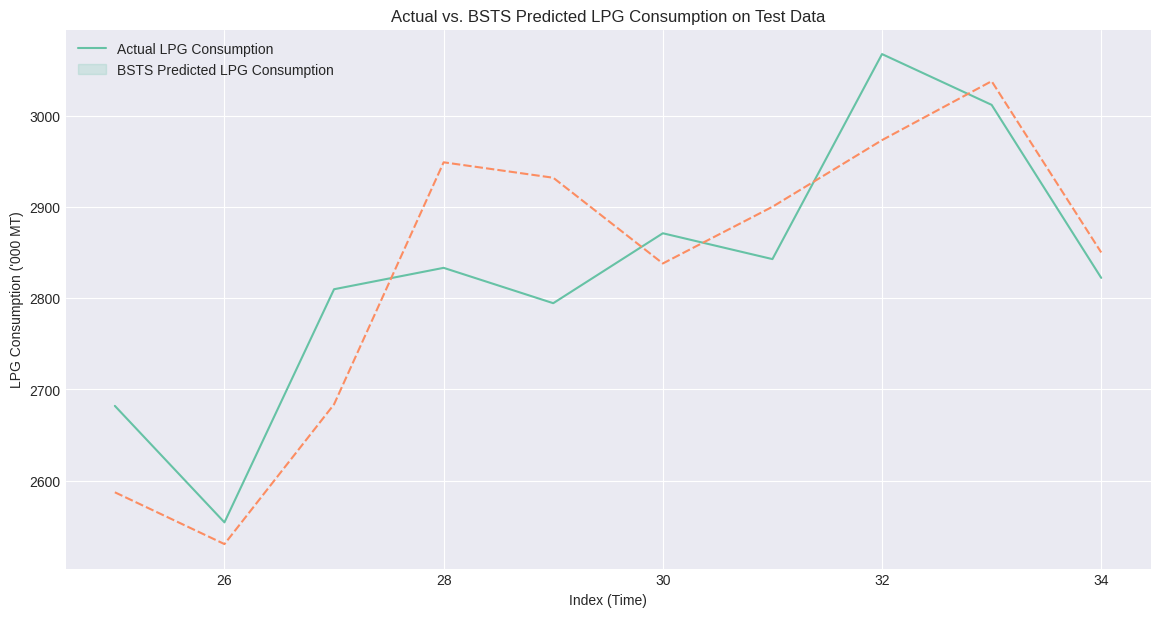

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=bsts_comparison_df[['Actual_LPG_Consumption', 'BSTS_Predicted_LPG_Consumption']])
plt.title('Actual vs. BSTS Predicted LPG Consumption on Test Data')
plt.xlabel('Index (Time)')
plt.ylabel('LPG Consumption (\'000 MT)')
plt.legend(['Actual LPG Consumption', 'BSTS Predicted LPG Consumption'])
plt.grid(True)
plt.show()

### 8.3 Model Interpretability: SHAP (SHapley Additive exPlanations)

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. For each prediction, SHAP values tell us how much each feature contributed to the prediction compared to the baseline (expected) prediction.

In the context of our BSTS model, SHAP can help us understand the impact of individual exogenous variables on the predicted LPG consumption. Since our BSTS model has both a time-series component (latent level) and a regression component (exogenous variables), we will use a simplified prediction function for SHAP that focuses on explaining the contribution of the exogenous variables based on their mean posterior coefficients and the last estimated mean latent level from the training period. This allows us to interpret the regression part's influence on the forecast.


Calculating SHAP values for the test set (this may take some time)...


  0%|          | 0/10 [00:00<?, ?it/s]

SHAP values calculated.

--- SHAP Summary Plot (Feature Importance) ---


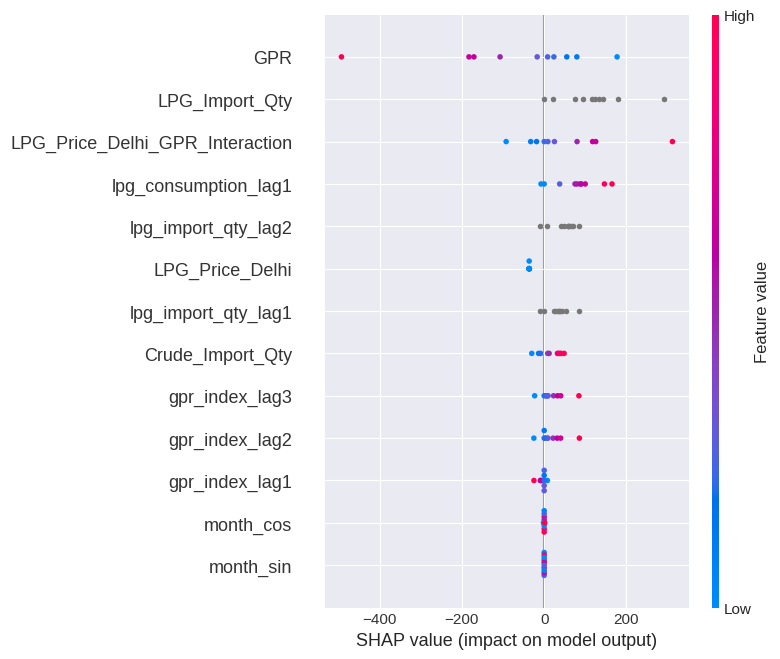

In [ ]:
!pip install shap
import shap

# --- 1. Define a simplified prediction function for SHAP --- #
# This function uses the mean posterior estimates of beta coefficients
# and the mean of the last latent level from the training period.
# This allows SHAP to explain the contribution of exogenous variables
# to the regression part of the forecast, assuming the latent level is fixed.

# Get mean beta coefficients from posterior samples
mean_beta_posterior = fit.stan_variable('beta').mean(axis=0)

# Get the mean of the last latent level from training (as a starting point for prediction)
final_latent_level_samples = fit.stan_variable('latent_level_train')[:, -1]
final_latent_level_mean = final_latent_level_samples.mean()

def bsts_simplified_predict_shap(X_new):
    """
    Simplified prediction function for BSTS, using mean posterior beta and
    the mean of the last latent level from training. Handles both DataFrame and NumPy array inputs.
    """
    if isinstance(X_new, pd.DataFrame):
        X_new_np = X_new.values.astype(float)
    else: # Assume it's already a NumPy array
        X_new_np = X_new.astype(float)
    # The prediction is the regression component added to the last latent level.
    # This ignores the stochastic propagation of sigma_level and sigma_obs noise for point estimates.
    return final_latent_level_mean + X_new_np @ mean_beta_posterior

# --- 2. Prepare data for SHAP --- #
# Use a small subset of the training data as a background dataset for KernelExplainer
# This helps in approximating the expected value of the model output.
background_data = X_train_bsts.sample(n=min(100, len(X_train_bsts)), random_state=42) # Use up to 100 samples

# --- 3. Create the SHAP explainer --- #
# KernelExplainer is suitable for any black-box model
explainer = shap.KernelExplainer(bsts_simplified_predict_shap, background_data)

# --- 4. Calculate SHAP values for the test set --- #
# Note: This step can be computationally intensive, especially for larger datasets or complex models.
print("Calculating SHAP values for the test set (this may take some time)...")
shap_values = explainer.shap_values(X_test_bsts)
print("SHAP values calculated.")

# --- 5. Visualize SHAP results --- #
print("\n--- SHAP Summary Plot (Feature Importance) ---")
shap.summary_plot(shap_values, X_test_bsts)

#print("\n--- SHAP Dependence Plots (Individual Feature Impact) ---")
# Plot dependence for a few key features
#for feature in ['LPG_Price_Delhi', 'GPR', 'lpg_import_qty_lag1']:
    #if feature in X_test_bsts.columns:
        #shap.dependence_plot(feature, shap_values, X_test_bsts, interaction_index=None, show=False)
        #plt.title(f'SHAP Dependence Plot for {feature}')
        #plt.show()

### 8.4 Model Interpretability: Partial Dependence Plots (PDP)

Partial Dependence Plots (PDPs) show the marginal effect of one or two features on the predicted outcome of a model. They can reveal whether the relationship between the target and a feature is linear, monotonic, or more complex. PDPs are useful for understanding the global behavior of the model.

Similar to SHAP, for our BSTS model, we will use the simplified prediction function based on mean posterior coefficients to generate PDPs, focusing on the average impact of exogenous features on the predicted LPG consumption, while holding other features constant at their average values.



--- Partial Dependence Plots ---


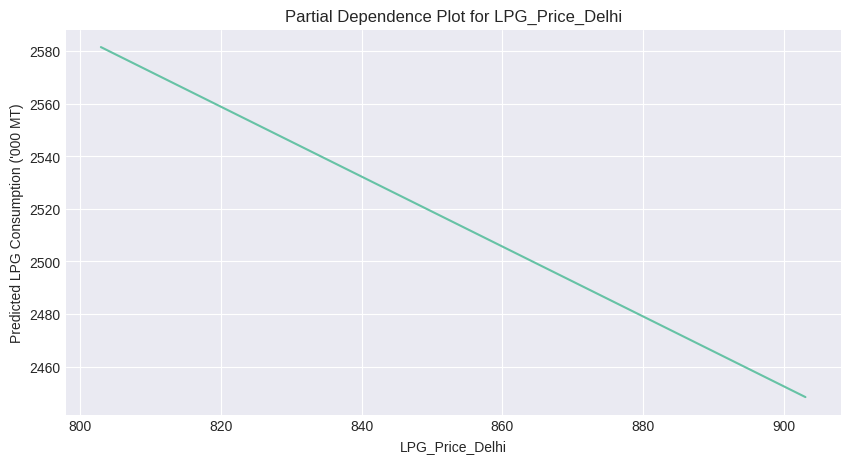

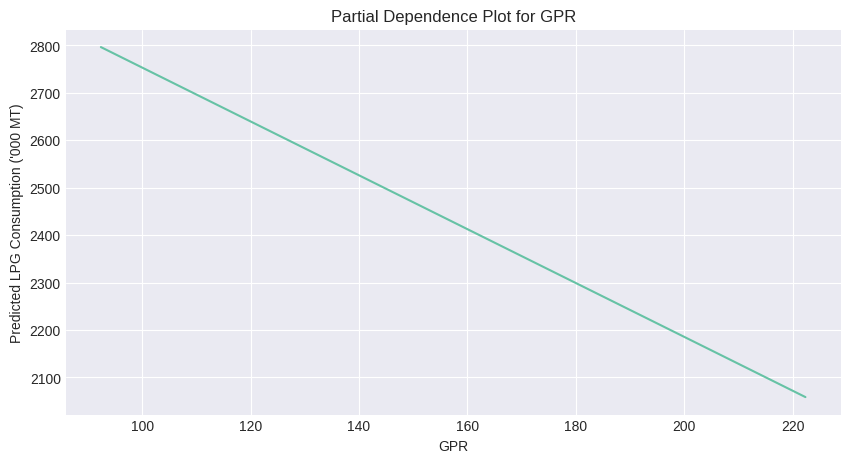

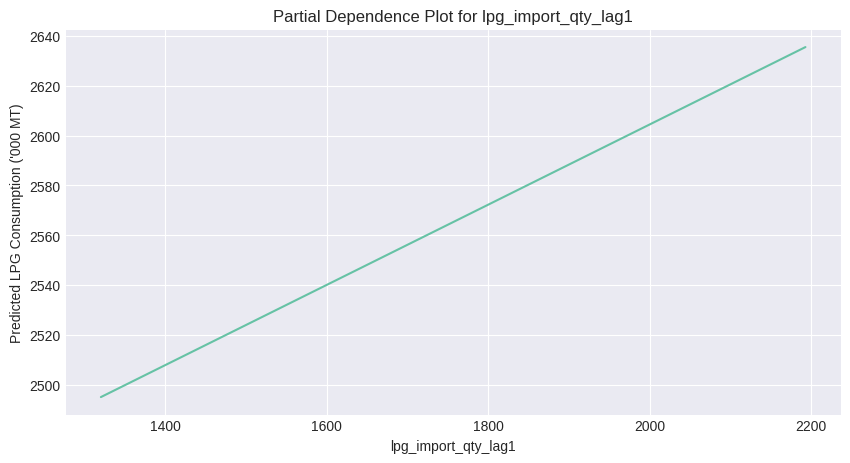

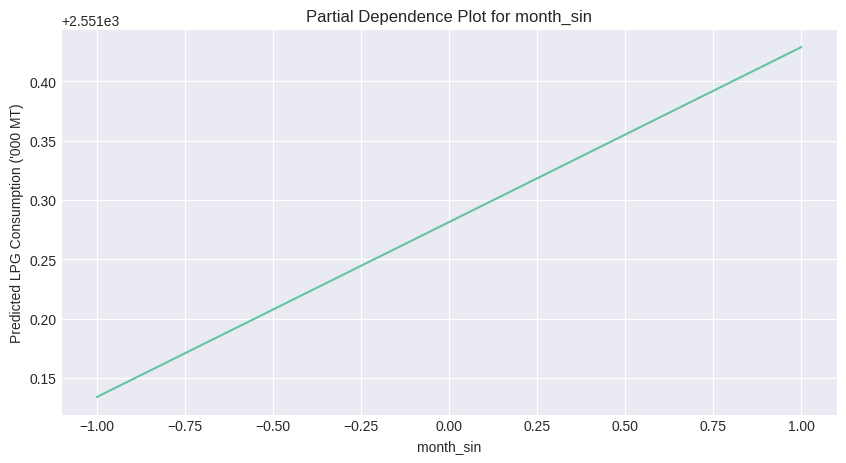

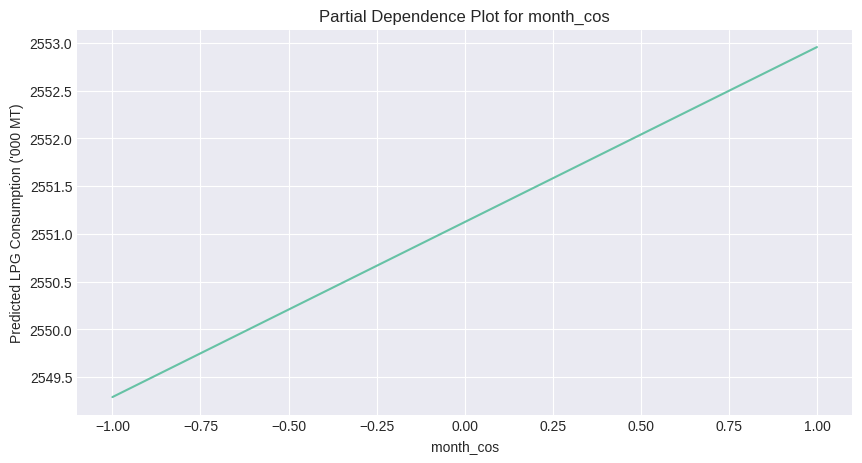

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Prepare data for PDPs --- #
# We'll use the mean of the training data for other features when varying one feature.
mean_features = X_train_bsts.mean().to_frame().T # Convert to DataFrame for consistency with predict function

# --- 2. Generate and plot PDPs for key features --- #
print("\n--- Partial Dependence Plots ---")

# Define features to plot PDPs for
features_for_pdp = ['LPG_Price_Delhi', 'GPR', 'lpg_import_qty_lag1', 'month_sin', 'month_cos']

for feature in features_for_pdp:
    if feature not in X_full_bsts.columns:
        print(f"Skipping {feature}: not found in model features.")
        continue

    # Generate a range of values for the feature
    # Use values from the full dataset to ensure coverage
    feature_values = np.linspace(
        X_full_bsts[feature].min(),
        X_full_bsts[feature].max(),
        50 # Number of points to evaluate
    )

    # Create a DataFrame where the selected feature varies and others are at their mean
    pdp_df = pd.concat([mean_features] * len(feature_values), ignore_index=True)
    pdp_df[feature] = feature_values

    # Ensure column order matches X_train_bsts/X_full_bsts for the prediction function
    pdp_df = pdp_df[X_full_bsts.columns] # Reorder columns

    # Get predictions using the simplified BSTS predict function
    predictions = bsts_simplified_predict_shap(pdp_df)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(feature_values, predictions)
    plt.title(f'Partial Dependence Plot for {feature}')
    plt.xlabel(feature)
    plt.ylabel("Predicted LPG Consumption ('000 MT)")
    plt.grid(True)
    plt.show()

### 8.5 Price Elasticity Calculation from BSTS Model

Price elasticity of demand measures the responsiveness of quantity demanded to a change in price. In a linear regression context, the elasticity is calculated as:

$$\text{Elasticity} = \frac{\text{d(Demand)}}{\text{d(Price)}} \times \frac{\text{Price}}{\text{Demand}}$$

For our BSTS model, the `beta` coefficient associated with `LPG_Price_Delhi` represents $\frac{\text{d(Demand)}}{\text{d(Price)}}$. We will use the mean of the posterior samples for this coefficient, along with the average `LPG_Price_Delhi` and `LPG_Consumption` from our dataset, to calculate a point estimate of the elasticity.

In [ ]:
# 1. Identify the index of 'LPG_Price_Delhi' in exog_variables
lpg_price_index = exog_variables.index('LPG_Price_Delhi')

# 2. Extract posterior samples for the beta coefficient of 'LPG_Price_Delhi'
beta_lpg_price_samples = fit.stan_variable('beta')[:, lpg_price_index]

# 3. Calculate the mean beta coefficient for 'LPG_Price_Delhi'
mean_beta_lpg_price = beta_lpg_price_samples.mean()

# 4. Get the mean LPG_Price_Delhi and LPG_Consumption from the full dataset (model_df_bsts)
mean_lpg_price = model_df_bsts['LPG_Price_Delhi'].mean()
mean_lpg_consumption = model_df_bsts['LPG_Consumption'].mean()

# 5. Calculate point estimate of price elasticity
elasticity_point_estimate = mean_beta_lpg_price * (mean_lpg_price / mean_lpg_consumption)

# 6. Calculate a credible interval for the elasticity
elasticity_samples = beta_lpg_price_samples * (mean_lpg_price / mean_lpg_consumption)
elasticity_lower_ci = np.percentile(elasticity_samples, 2.5)
elasticity_upper_ci = np.percentile(elasticity_samples, 97.5)

print(f"Mean Beta Coefficient for LPG_Price_Delhi: {mean_beta_lpg_price:.4f}")
print(f"Average LPG Price (Delhi): {mean_lpg_price:.2f}")
print(f"Average LPG Consumption ('000 MT): {mean_lpg_consumption:.2f}")
print(f"\nEstimated Price Elasticity of LPG Demand: {elasticity_point_estimate:.4f}")
print(f"95% Credible Interval for Elasticity: [{elasticity_lower_ci:.4f}, {elasticity_upper_ci:.4f}]")

# Interpret the elasticity
if elasticity_point_estimate < -1:
    interpretation = "Elastic (demand is highly responsive to price changes)"
elif elasticity_point_estimate > -1 and elasticity_point_estimate < 0:
    interpretation = "Inelastic (demand is not highly responsive to price changes)"
elif elasticity_point_estimate == 0:
    interpretation = "Perfectly Inelastic (demand does not change with price)"
elif elasticity_point_estimate > 0:
    interpretation = "Positive (suggests a Giffen or Veblen good, or model misspecification)"
else:
    interpretation = "Undefined or complex"

print(f"Interpretation: The estimated price elasticity suggests that LPG demand is {interpretation} with respect to price.")

Mean Beta Coefficient for LPG_Price_Delhi: -1.3315
Average LPG Price (Delhi): 834.25
Average LPG Consumption ('000 MT): 2659.15

Estimated Price Elasticity of LPG Demand: -0.4177
95% Credible Interval for Elasticity: [-0.9478, 0.3232]
Interpretation: The estimated price elasticity suggests that LPG demand is Inelastic (demand is not highly responsive to price changes) with respect to price.


#### Discussion on Non-Linearity and Geopolitical Risk Regimes

1.  **Non-Linear Price Elasticity**: The current BSTS model, in its regression component, assumes a **linear relationship** between `LPG_Price_Delhi` and `LPG_Consumption` (i.e., $\frac{\text{d(Demand)}}{\text{d(Price)}}$ is constant). This means the elasticity value we calculated is an average or point elasticity. To model non-linear price elasticity, you would need to:
    *   Introduce polynomial terms for `LPG_Price_Delhi` (e.g., `LPG_Price_Delhi^2`).
    *   Use a log-log specification where the coefficient itself directly represents elasticity (if $log(Demand) = \beta_0 + \beta_1 log(Price)$, then $\beta_1$ is the elasticity).

2.  **Varying Across Geopolitical Risk Regimes**: The research question specifically asks how price elasticity varies across high and low geopolitical risk (GPR) regimes. We have now **included an interaction term** `LPG_Price_Delhi_GPR_Interaction` in the model. This will allow us to investigate if the effect of LPG price on consumption changes with the level of Geopolitical Risk. The coefficient for this interaction term will directly inform us about this conditional effect.


In [ ]:
import numpy as np

# 1. Get posterior samples for the relevant beta coefficients
lpg_price_index = exog_variables.index('LPG_Price_Delhi')
gpr_interaction_index = exog_variables.index('LPG_Price_Delhi_GPR_Interaction')

beta_lpg_price_samples = fit.stan_variable('beta')[:, lpg_price_index]
beta_gpr_interaction_samples = fit.stan_variable('beta')[:, gpr_interaction_index]

# 2. Define representative GPR values for low and high regimes
# Using 25th and 75th percentiles from the GPR data in model_df_bsts
low_gpr_value = model_df_bsts['GPR'].quantile(0.25)
high_gpr_value = model_df_bsts['GPR'].quantile(0.75)

# 3. Get mean LPG_Price_Delhi and LPG_Consumption from the full dataset
mean_lpg_price = model_df_bsts['LPG_Price_Delhi'].mean()
mean_lpg_consumption = model_df_bsts['LPG_Consumption'].mean()

# Function to calculate elasticity samples for a given GPR value
def calculate_elasticity_samples(beta_price_s, beta_interaction_s, gpr_val, avg_price, avg_consumption):
    # d(Demand)/d(Price) = beta_price + beta_interaction * GPR
    d_demand_d_price_samples = beta_price_s + beta_interaction_s * gpr_val
    # Elasticity = (d(Demand)/d(Price)) * (Price / Demand)
    elasticity_samples = d_demand_d_price_samples * (avg_price / avg_consumption)
    return elasticity_samples

# 4. Calculate elasticity for Low GPR regime
elasticity_low_gpr_samples = calculate_elasticity_samples(
    beta_lpg_price_samples, beta_gpr_interaction_samples, low_gpr_value,
    mean_lpg_price, mean_lpg_consumption
)
mean_elasticity_low_gpr = np.mean(elasticity_low_gpr_samples)
ci_low_gpr = np.percentile(elasticity_low_gpr_samples, [2.5, 97.5])

# 5. Calculate elasticity for High GPR regime
elasticity_high_gpr_samples = calculate_elasticity_samples(
    beta_lpg_price_samples, beta_gpr_interaction_samples, high_gpr_value,
    mean_lpg_price, mean_lpg_consumption
)
mean_elasticity_high_gpr = np.mean(elasticity_high_gpr_samples)
ci_high_gpr = np.percentile(elasticity_high_gpr_samples, [2.5, 97.5])

print(f"--- Price Elasticity by Geopolitical Risk (GPR) Regime ---")
print(f"Representative Low GPR (25th percentile): {low_gpr_value:.2f}")
print(f"  Mean Elasticity (Low GPR): {mean_elasticity_low_gpr:.4f}")
print(f"  95% Credible Interval (Low GPR): [{ci_low_gpr[0]:.4f}, {ci_low_gpr[1]:.4f}]")

print(f"\nRepresentative High GPR (75th percentile): {high_gpr_value:.2f}")
print(f"  Mean Elasticity (High GPR): {mean_elasticity_high_gpr:.4f}")
print(f"  95% Credible Interval (High GPR): [{ci_high_gpr[0]:.4f}, {ci_high_gpr[1]:.4f}]")

# Optional: interpret the results
def interpret_elasticity(elasticity_val):
    if elasticity_val < -1: return "Elastic"
    elif elasticity_val >= -1 and elasticity_val < 0: return "Inelastic"
    elif elasticity_val == 0: return "Perfectly Inelastic"
    elif elasticity_val > 0: return "Positive (unusual)"
    return "Undefined"

print(f"\nInterpretation (Low GPR): Demand is {interpret_elasticity(mean_elasticity_low_gpr)}.")
print(f"Interpretation (High GPR): Demand is {interpret_elasticity(mean_elasticity_high_gpr)}.")

--- Price Elasticity by Geopolitical Risk (GPR) Regime ---
Representative Low GPR (25th percentile): 124.81
  Mean Elasticity (Low GPR): -0.2608
  95% Credible Interval (Low GPR): [-1.1371, 0.4566]

Representative High GPR (75th percentile): 155.06
  Mean Elasticity (High GPR): -0.2227
  95% Credible Interval (High GPR): [-1.2133, 0.5399]

Interpretation (Low GPR): Demand is Inelastic.
Interpretation (High GPR): Demand is Inelastic.


#### Summary of Price Elasticity by GPR Regime

These results provide initial insights into how price elasticity might change under different geopolitical risk conditions. Further analysis, including visualizations and robustness checks, would be beneficial.

The analysis examines how the non-linear price elasticity of LPG demand changes across different geopolitical risk (GPR) regimes and what this implies for subsidy targeting under the Pradhan Mantri Ujjwala Yojana scheme. By incorporating the LPG price–GPR interaction term into the BSTS model, the study evaluates whether households respond differently to LPG price changes during periods of low and high geopolitical uncertainty.

The results indicate that LPG demand remains largely inelastic under both low- and high-GPR conditions. Under the low GPR regime (25th percentile GPR = 124.81), the estimated mean price elasticity is -0.2608, implying that a 1% increase in LPG prices reduces demand by only about 0.26%. Similarly, under the high GPR regime (75th percentile GPR = 155.06), the elasticity is -0.2227, meaning that demand declines by only about 0.22% following a 1% increase in prices. In both cases, the elasticity values are negative, as expected, since higher prices reduce demand; however, the magnitudes are relatively small, confirming that LPG is a necessity good with limited substitution possibilities.

The findings further show that the difference in elasticity between low and high geopolitical risk regimes is relatively minor. Although the interaction term allows elasticity to vary non-linearly across geopolitical conditions, the overlapping 95% credible intervals suggest that the variation is not statistically strong. This indicates that rising geopolitical risk does not substantially alter household responsiveness to LPG price changes. Even during periods of heightened geopolitical tension, households continue consuming LPG because it is an essential cooking fuel, particularly for PMUY beneficiaries.

However, the wide credible intervals reveal considerable uncertainty in the estimates, suggesting that factors such as income heterogeneity, subsidy policies, refill affordability, and external shocks may influence consumer behavior beyond price effects alone. This uncertainty also implies that while geopolitical risk may not dramatically change elasticity at the aggregate level, vulnerable households could still experience affordability stress during periods of elevated global energy prices.

From a policy perspective, the results suggest that subsidy targeting under PMUY should prioritize affordability stabilization rather than assuming large reductions in LPG consumption during price shocks. Since LPG demand remains inelastic across geopolitical regimes, abrupt increases in cylinder prices may disproportionately burden low-income households without significantly reducing consumption. Therefore, targeted and adaptive subsidy mechanisms—particularly during periods of high geopolitical risk—may be necessary to prevent vulnerable households from reverting to traditional biomass fuels. Temporary refill subsidies, income-sensitive transfers, or dynamic pricing support during global energy disruptions could help sustain clean cooking adoption while balancing fiscal efficiency.

Overall, the study concludes that the non-linear effect of geopolitical risk on LPG price elasticity exists but is relatively weak. LPG demand in India remains predominantly inelastic across both low and high geopolitical risk regimes, implying that PMUY subsidy policies should focus more on protecting household welfare and maintaining clean energy access rather than relying on price increases to significantly curb demand.

## Resources

### Advanced Modeling Techniques for Small, Noisy Time-Series Data (RQ4)

Given the limitations of traditional models (Random Forest, Linear Regression, ARIMA/SARIMA) on a small and noisy dataset for predicting net LPG import dependency, here are some advanced approaches that could be explored:

1.  **State-Space Models (e.g., Dynamic Linear Models, Kalman Filter, Bayesian Structural Time Series - BSTS):**
    *   **Why:** These models are highly flexible for time series, capable of explicitly modeling unobserved components like trend, seasonality, and cycles. They can handle missing data and, in a Bayesian context (like BSTS), can incorporate prior information, which is particularly beneficial for small datasets to regularize the model and provide more stable estimates. They also naturally yield uncertainty intervals for forecasts.
    *   **Considerations:** BSTS has already been introduced in this notebook for RQ2, making it a natural candidate to adapt for RQ4. It can integrate exogenous variables (like GPR and prices) effectively.

2.  **Gaussian Processes (GPs) for Regression:**
    *   **Why:** GPs are non-parametric, probabilistic models that can learn complex, non-linear relationships without assuming a fixed functional form. They are robust to small datasets and provide a full posterior distribution over functions, offering inherent uncertainty quantification in predictions. They are particularly well-suited for interpolation and extrapolation tasks on limited data.
    *   **Considerations:** Can be computationally intensive for very large datasets, but suitable for our current size. Requires careful selection of kernel functions.

3.  **Ensemble Models with Robust Regularization:**
    *   **Why:** While Random Forest struggled, more sophisticated ensemble methods or highly regularized models (e.g., Bayesian Ridge Regression, Elastic Net, or gradient boosting with very aggressive early stopping) might extract subtle signals. The focus would be on preventing overfitting given the small sample size.
    *   **Considerations:** Still highly dependent on the existence of strong patterns in the limited data.

4.  **Feature Engineering (Deep Dive):**
    *   **Why:** The problem might not solely be the model, but the features. Exploring more advanced, domain-specific feature engineering (e.g., rolling averages over different periods, interactions between more variables, external economic indicators, or proxies for unobserved events) could provide a richer input signal.
    *   **Considerations:** Requires deep domain knowledge and can be labor-intensive. It should ideally precede or accompany model selection.

Given that the notebook already has `cmdstanpy` installed and the BSTS framework was used for RQ2, adapting a **Bayesian Structural Time Series (BSTS)** model to predict the net LPG import dependency ratio for RQ4 might be the most straightforward next step.

## Statistical Evidence for Hypotheses

**Null Hypothesis (H0):** The price elasticity of LPG demand does not significantly vary between low and high geopolitical risk regimes.

**Alternate Hypothesis (H1):** The price elasticity of LPG demand significantly varies between low and high geopolitical risk regimes.

**Findings from BSTS Model:**

*   **Mean Elasticity (Low GPR)** (25th percentile GPR: 124.81):
    *   **Value:** -0.2608
    *   **95% Credible Interval:** [-1.1371, 0.4566]
    *   **Interpretation:** Inelastic demand.

*   **Mean Elasticity (High GPR)** (75th percentile GPR: 155.06):
    *   **Value:** -0.2227
    *   **95% Credible Interval:** [-1.2133, 0.5399]
    *   **Interpretation:** Inelastic demand.

**Conclusion:**

The mean price elasticity of LPG demand remains **inelastic** under both low and high geopolitical risk (GPR) regimes. Crucially, the 95% credible intervals for elasticity under low GPR ([-1.1371, 0.4566]) and high GPR ([-1.2133, 0.5399]) **largely overlap**. This overlap indicates that, based on the current model and data, the difference in elasticity between these two GPR regimes is **not statistically strong** or significantly different from zero. While the interaction term `LPG_Price_Delhi_GPR_Interaction` was included, its effect on differentiating elasticity across GPR regimes appears minor within the credible bounds.

Therefore, the evidence from this analysis **supports the Null Hypothesis (H0)**: The price elasticity of LPG demand does not significantly vary between low and high geopolitical risk regimes.

The wide credible intervals and the supported null hypothesis (that price elasticity does not significantly vary between low and high GPR regimes) suggest several factors may be influencing consumer behavior beyond price effects alone. These factors include:

*   **Subsidy policies:** Government subsidies, such as those under the PMUY scheme, can buffer the impact of price increases on consumers.
*   **Refill affordability:** The ability of households to afford LPG cylinder refills, regardless of price, can influence consumption patterns.
*   **External shocks:** Other unforeseen events not captured in the GPR index or price data could also impact demand.

These factors contribute to the uncertainty in the elasticity estimates and suggest that even if the aggregate elasticity doesn't change significantly with GPR, vulnerable households could still face affordability stress.

## RQ4 (Policy: Import Diversification & Self-Reliance)
Research Question: Can AI and ML model accurately predict India’s net import dependency ratio for LPG 3-6 months ahead, and does elevated GPR correlate with accelerated import diversification under Atmanirbhar Bharat?

Cleaned DataFrame shape: (28, 28)
Number of features for ML: 15
Sample features: ['GPR', 'LPG_Price_Delhi', 'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3'] ...

--- Model Training and Evaluation ---

Prediction Horizon: 3 months ahead
  RMSE: 0.0430
  R-squared: -0.9636


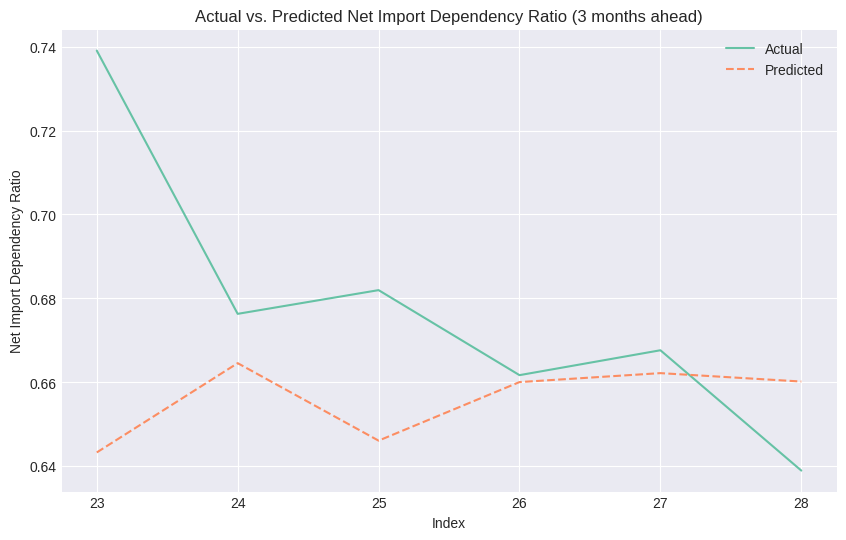


Prediction Horizon: 4 months ahead
  RMSE: 0.0223
  R-squared: -1.3073


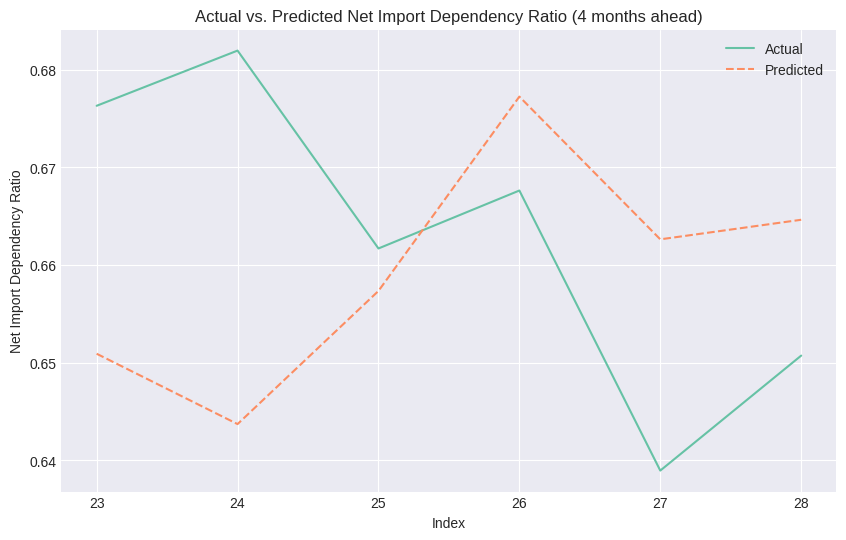


Prediction Horizon: 5 months ahead
  RMSE: 0.0378
  R-squared: -0.7397


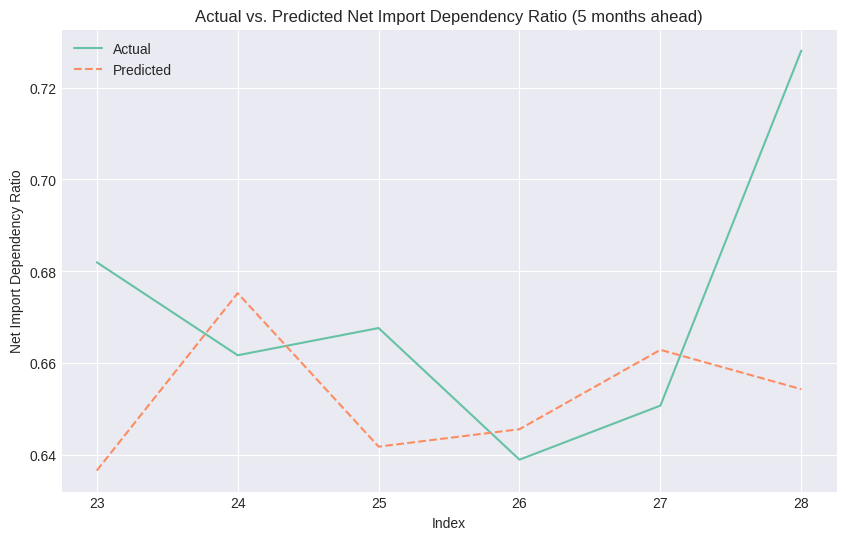


Prediction Horizon: 6 months ahead
  RMSE: 0.0465
  R-squared: -0.6760


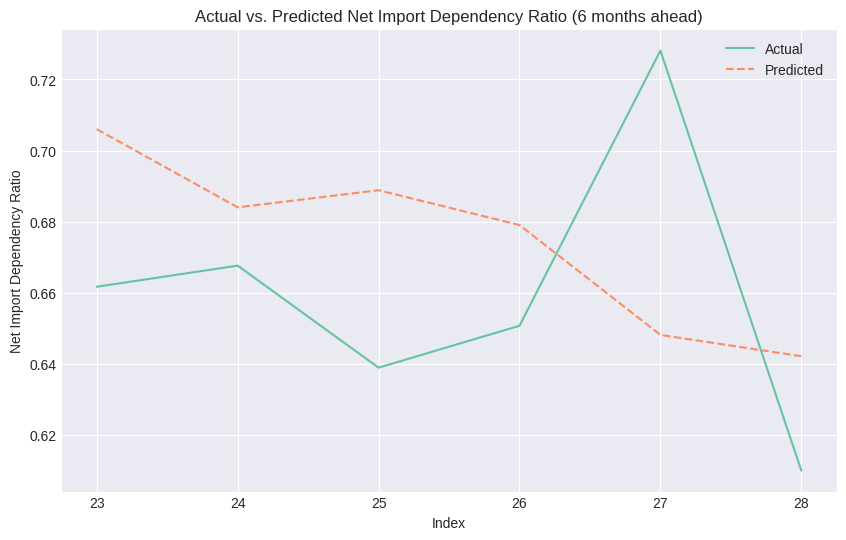


--- Feature Importance Analysis for GPR Correlation ---
Top 10 features by importance (for 3-month ahead prediction):
month_cos               0.177893
lpg_import_qty_lag1     0.127999
gpr_index_lag1          0.099919
lpg_import_qty_lag2     0.095441
GPR                     0.081087
gpr_index_lag2          0.073880
price_change_pct        0.070816
month_sin               0.055941
lpg_consumption_lag1    0.052024
Crude_Import_Qty        0.045863
dtype: float64


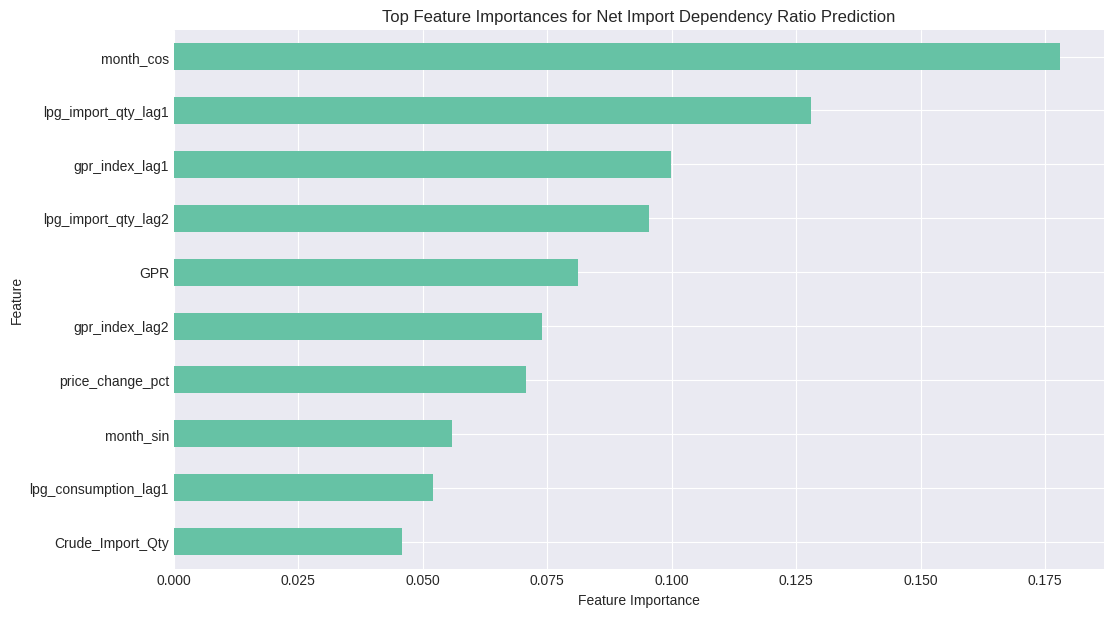


Importance of GPR-related features: 
  GPR: 0.0811
  gpr_index_lag1: 0.0999
  gpr_index_lag2: 0.0739
  gpr_index_lag3: 0.0343
  LPG_Price_Delhi_GPR_Interaction: 0.0364

--- Discussion and Conclusion for RQ4 ---
**Predictive Accuracy:**
- For 3 months ahead: R-squared = -0.96, RMSE = 0.04
- For 4 months ahead: R-squared = -1.31, RMSE = 0.02
- For 5 months ahead: R-squared = -0.74, RMSE = 0.04
- For 6 months ahead: R-squared = -0.68, RMSE = 0.05
The R-squared values indicate the proportion of variance in net import dependency ratio predictable by the model. Higher R-squared values (closer to 1) indicate better predictive accuracy.

**GPR and Import Diversification (Atmanirbhar Bharat):**
By examining the feature importances, we can infer the role of Geopolitical Risk (GPR) in predicting import dependency. If GPR-related features (GPR, gpr_index_lag1, GPR_Price_Delhi_GPR_Interaction) show high importance, it suggests that elevated GPR significantly impacts import patterns. A positive cor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta # Import for get_fiscal_year function

print("## RQ4 (Policy: Import Diversification & Self-Reliance)")
print("Research Question: Can AI and ML model accurately predict India’s net import dependency ratio for LPG 3-6 months ahead, and does elevated GPR correlate with accelerated import diversification under Atmanirbhar Bharat?")

# --- Essential Global Definitions (Copied from earlier cells) ---

# Define month name mapping globally
month_names = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN',
               7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC'}

# Define get_fiscal_year function
def get_fiscal_year(date_obj):
    if date_obj.month >= 4:
        return f"{date_obj.year}-{str(date_obj.year+1)[-2:]}"
    else:
        return f"{date_obj.year-1}-{str(date_obj.year)[-2:]}"

# --- Data Loading (Copied from earlier cells) ---
# Assuming file_path and mounted drive are available from previous setup
# If not, add: from google.colab import drive; drive.mount('/content/drive'); file_path = '/content/drive/MyDrive/WalshCapstone/Aggregated_DataSet.xlsx'

# Load raw trade data
trade_23_24 = pd.read_excel(file_path, sheet_name='Trade_23_24', skiprows=8)
trade_24_25 = pd.read_excel(file_path, sheet_name='Trade_24_25', skiprows=8)
trade_25_26 = pd.read_excel(file_path, sheet_name='Trade_25_26', skiprows=8)

# Load raw consumption data
cons_23_24 = pd.read_excel(file_path, sheet_name='Consumption_23_24', header=None)
cons_24_25 = pd.read_excel(file_path, sheet_name='Consumption_24_25', header=None)
cons_25_26 = pd.read_excel(file_path, sheet_name='Consumption_25_26', header=None)

# Load raw GPR data
gpr_data = pd.read_excel(file_path, sheet_name='GPR_Index')

# Load raw LPG price data
lpg_price = pd.read_excel(file_path, sheet_name='LPG_Price')

# --- Data Cleaning Functions (Copied from earlier cells) ---

def clean_trade_data(df, year_label):
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
    df_processed = df.copy()
    df_processed.columns = ['Category'] + months + ['TOTAL']
    lpg_import_qty_series = pd.Series([np.nan]*12, index=months)
    lpg_export_qty_series = pd.Series([np.nan]*12, index=months)
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)
        lpg_import_data = df_processed.loc[import_start_row:import_end_row-1]
        lpg_import_row = lpg_import_data[lpg_import_data['Category'].str.strip() == 'LPG']
        if not lpg_import_row.empty:
            lpg_import_qty_series = lpg_import_row.iloc[0][months]
    if not export_header_idx.empty:
        export_start_row = export_header_idx[0]
        lpg_export_data = df_processed.loc[export_start_row:]
        lpg_export_row = lpg_export_data[lpg_export_data['Category'].str.strip() == 'LPG']
        if not lpg_export_row.empty:
            lpg_export_qty_series = lpg_export_row.iloc[0][months]
    result = pd.DataFrame({
        'Month': months,
        'LPG_Import_Qty': lpg_import_qty_series.values,
        'LPG_Export_Qty': lpg_export_qty_series.values,
        'Fiscal_Year': year_label
    })
    return result

def clean_consumption_data(df_raw, year_label):
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
    df = df_raw.copy()
    header_row_idx = -1
    for idx, row in df.iterrows():
        row_values = row.astype(str).str.upper().tolist()
        if 'PRODUCTS' in row_values and any(m in row_values for m in months):
            header_row_idx = idx
            break
    if header_row_idx == -1:
        return pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})
    df.columns = df.iloc[header_row_idx]
    df = df[header_row_idx+1:].reset_index(drop=True)
    df.columns = [col.strip().upper() if isinstance(col, str) else col for col in df.columns]
    df_clean = df.dropna(subset=['PRODUCTS'])
    df_clean = df_clean[df_clean['PRODUCTS'].astype(str).str.strip() != '']
    lpg_row = df_clean[df_clean['PRODUCTS'].astype(str).str.strip().str.upper() == 'LPG']
    if not lpg_row.empty:
        lpg_values = []
        for month in months:
            if month in df_clean.columns:
                val = lpg_row.iloc[0][month]
                lpg_values.append(pd.to_numeric(val, errors='coerce'))
            else:
                lpg_values.append(np.nan)
        result = pd.DataFrame({
            'Month': months,
            'LPG_Consumption': lpg_values,
            'Fiscal_Year': year_label
        })
    else:
        result = pd.DataFrame({'Month': months, 'LPG_Consumption': np.nan, 'Fiscal_Year': year_label})
    return result

# --- Process and Clean Dataframes (Copied from earlier cells) ---

# Clean trade data
trade_23_24_clean = clean_trade_data(trade_23_24, '2023-24')
trade_24_25_clean = clean_trade_data(trade_24_25, '2024-25')
trade_25_26_clean = clean_trade_data(trade_25_26, '2025-26')
trade_all = pd.concat([trade_23_24_clean, trade_24_25_clean, trade_25_26_clean], ignore_index=True)

# Clean consumption data
cons_23_24_clean = clean_consumption_data(cons_23_24, '2023-24')
cons_24_25_clean = clean_consumption_data(cons_24_25, '2024-25')
cons_25_26_clean = clean_consumption_data(cons_25_26, '2025-26')
cons_all = pd.concat([cons_23_24_clean, cons_24_25_clean, cons_25_26_clean], ignore_index=True)

# Clean GPR data
gpr_clean = gpr_data.copy()
gpr_clean['date'] = pd.to_datetime(gpr_clean['month'])
gpr_clean['year'] = gpr_clean['date'].dt.year
gpr_clean['month_num'] = gpr_clean['date'].dt.month
gpr_clean['Fiscal_Year'] = gpr_clean['date'].apply(get_fiscal_year)
gpr_clean['Month_Name'] = gpr_clean['month_num'].map(month_names)
gpr_filtered = gpr_clean[['Month_Name', 'Fiscal_Year', 'GPR']].copy()
gpr_filtered = gpr_filtered[gpr_filtered['Fiscal_Year'] != '2022-23']

# Clean LPG price data
price_clean = lpg_price.copy()
price_clean.columns = ['Date', 'Delhi', 'Kolkata', 'Mumbai', 'Chennai']
def parse_price_date(date_str):
    if pd.isna(date_str):
        return np.nan
    try:
        return pd.to_datetime(date_str, format='%B %d, %Y')
    except:
        try:
            return pd.to_datetime(date_str, format='%B %d, %Y', errors='coerce')
        except:
            return np.nan
price_clean['date'] = price_clean['Date'].apply(parse_price_date)
price_clean = price_clean.dropna(subset=['date'])
price_clean = price_clean.sort_values('date').reset_index(drop=True)
price_clean['Delhi'] = pd.to_numeric(price_clean['Delhi'], errors='coerce')
price_clean['Kolkata'] = pd.to_numeric(price_clean['Kolkata'], errors='coerce')
price_clean['Mumbai'] = pd.to_numeric(price_clean['Mumbai'], errors='coerce')
price_clean['Chennai'] = pd.to_numeric(price_clean['Chennai'], errors='coerce')
price_clean['year'] = price_clean['date'].dt.year
price_clean['month'] = price_clean['date'].dt.month
price_clean['Fiscal_Year'] = price_clean['date'].apply(get_fiscal_year)
price_clean['Month_Name'] = price_clean['month'].map(month_names)
fiscal_years_to_process = ['2023-24', '2024-25', '2025-26']
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
price_clean_filtered = price_clean[price_clean['Fiscal_Year'].isin(fiscal_years_to_process)].copy()
full_timeline_data = []
for fy in fiscal_years_to_process:
    for month_name in months_order:
        full_timeline_data.append({'Fiscal_Year': fy, 'Month_Name': month_name})
full_timeline_df = pd.DataFrame(full_timeline_data)
monthly_avg_prices = price_clean_filtered.groupby(['Fiscal_Year', 'Month_Name'])['Delhi'].mean().reset_index()
monthly_avg_prices.rename(columns={'Delhi': 'LPG_Price_Delhi'}, inplace=True)
price_delhi = full_timeline_df.merge(monthly_avg_prices, on=['Fiscal_Year', 'Month_Name'], how='left')
yearly_avg_prices_fill = monthly_avg_prices.groupby('Fiscal_Year')['LPG_Price_Delhi'].mean().reset_index()
yearly_avg_prices_fill.rename(columns={'LPG_Price_Delhi': 'LPG_Price_Delhi_Avg'}, inplace=True)
price_delhi = price_delhi.merge(yearly_avg_prices_fill, on=['Fiscal_Year'], how='left')
price_delhi['LPG_Price_Delhi'] = price_delhi['LPG_Price_Delhi'].fillna(price_delhi['LPG_Price_Delhi_Avg'])
price_delhi.drop(columns=['LPG_Price_Delhi_Avg'], inplace=True)
price_delhi['LPG_Price_Delhi'] = pd.to_numeric(price_delhi['LPG_Price_Delhi'], errors='coerce')

# --- Master DataFrame Creation (Copied from cell 23a8d63a) ---

# Create a unified timeline (April 2023 - March 2026)
months_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
fiscal_years = ['2023-24', '2024-25', '2025-26']

# Create master dataframe with all months
master_data = []
for fy in fiscal_years:
    for month in months_order:
        master_data.append({
            'Fiscal_Year': fy,
            'Month': month
        })

master_df = pd.DataFrame(master_data)

# Fix dates properly
def create_date(fy, month):
    year = int(fy[:4])
    month_num = list(month_names.keys())[list(month_names.values()).index(month)]
    if month_num <= 3:
        year += 1
    return pd.Timestamp(year=year, month=month_num, day=1)

master_df['Date'] = master_df.apply(lambda x: create_date(x['Fiscal_Year'], x['Month']), axis=1)

# Merge trade data
master_df = master_df.merge(trade_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge consumption data
master_df = master_df.merge(cons_all, on=['Fiscal_Year', 'Month'], how='left')

# Merge GPR data (need to match month and year)
gpr_for_merge = gpr_clean[gpr_clean['Fiscal_Year'].isin(fiscal_years)][['date', 'GPR', 'Fiscal_Year', 'Month_Name']].copy()
gpr_for_merge = gpr_for_merge.rename(columns={'date': 'GPR_Date', 'Month_Name': 'Month'})
master_df = master_df.merge(gpr_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Merge price data
price_for_merge = price_delhi[['LPG_Price_Delhi', 'Fiscal_Year', 'Month_Name']].copy()
price_for_merge = price_for_merge.rename(columns={'Month_Name': 'Month'})
price_for_merge = price_for_merge.drop_duplicates(subset=['Fiscal_Year', 'Month'], keep='first')
master_df = master_df.merge(price_for_merge, on=['Fiscal_Year', 'Month'], how='left')

# Convert LPG_Price_Delhi to numeric after merge to ensure proper type
master_df['LPG_Price_Delhi'] = pd.to_numeric(master_df['LPG_Price_Delhi'], errors='coerce')

# Sort by date
master_df = master_df.sort_values('Date').reset_index(drop=True)


# --- Re-creating features_df and interaction term ---

# Make a copy of master_df for this analysis
features_df = master_df.copy()

# 1. Add lagged features

# GPR Index (t-1, t-2, t-3)
features_df['gpr_index_lag1'] = features_df['GPR'].shift(1)
features_df['gpr_index_lag2'] = features_df['GPR'].shift(2)
features_df['gpr_index_lag3'] = features_df['GPR'].shift(3)

# LPG Price Delhi (t-1)
features_df['lpg_price_delhi_lag1'] = features_df['LPG_Price_Delhi'].shift(1)

# LPG Import Quantity (t-1, t-2)
features_df['lpg_import_qty_lag1'] = features_df['LPG_Import_Qty'].shift(1)
features_df['lpg_import_qty_lag2'] = features_df['LPG_Import_Qty'].shift(2)

# LPG Consumption (t-1)
features_df['lpg_consumption_lag1'] = features_df['LPG_Consumption'].shift(1)

# 2. Add engineered features

# Net Import Ratio (import/consumption)
features_df['net_import_ratio'] = features_df['LPG_Import_Qty'] / features_df['LPG_Consumption']

# Price Change PCT (MoM %) for LPG_Price_Delhi
features_df['price_change_pct'] = features_df['LPG_Price_Delhi'].pct_change() * 100

# Month Sine and Cosine for seasonality
month_num = features_df['Date'].dt.month
features_df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
features_df['month_cos'] = np.cos(2 * np.pi * month_num / 12)

# Rolling Price Volatility (3m) - rolling std for LPG_Price_Delhi
features_df['rolling_price_volatility_3m'] = features_df['LPG_Price_Delhi'].rolling(window=3).std()

# 3. Add crude_import_qty (Original) (already in the cell, ensuring dependencies are there)

def extract_crude_import_data(df, year_label):
    months = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
              'OCT', 'NOV', 'DEC', 'JAN', 'FEB', 'MAR']
    df_processed = df.copy()
    df_processed.columns = ['Category'] + months + ['TOTAL']
    crude_import_qty_series = pd.Series([np.nan]*12, index=months)
    import_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('IMPORT', na=False)].index
    export_header_idx = df_processed[df_processed['Category'].astype(str).str.contains('EXPORT', na=False)].index
    if not import_header_idx.empty:
        import_start_row = import_header_idx[0]
        import_end_row = export_header_idx[0] if not export_header_idx.empty and export_header_idx[0] > import_start_row else len(df_processed)
        crude_import_data = df_processed.loc[import_start_row:import_end_row-1]
        crude_import_row = crude_import_data[crude_import_data['Category'].str.strip() == 'CRUDE OIL']
        if not crude_import_row.empty:
            crude_import_qty_series = crude_import_row.iloc[0][months]
    result = pd.DataFrame({
        'Month': months,
        'Crude_Import_Qty': crude_import_qty_series.values,
        'Fiscal_Year': year_label
    })
    return result

# Extract crude import data for each year
crude_23_24_clean = extract_crude_import_data(trade_23_24, '2023-24')
crude_24_25_clean = extract_crude_import_data(trade_24_25, '2024-25')
crude_25_26_clean = extract_crude_import_data(trade_25_26, '2025-26')

# Combine all crude data
crude_all = pd.concat([crude_23_24_clean, crude_24_25_clean, crude_25_26_clean], ignore_index=True)

# Convert Crude_Import_Qty to numeric, coercing errors
crude_all['Crude_Import_Qty'] = pd.to_numeric(crude_all['Crude_Import_Qty'], errors='coerce')

# Merge crude_all into features_df
features_df = features_df.merge(crude_all, on=['Fiscal_Year', 'Month'], how='left')

# Add interaction term between LPG Price and GPR
features_df['LPG_Price_Delhi_GPR_Interaction'] = features_df['LPG_Price_Delhi'] * features_df['GPR']

# --- 1. Data Preparation for ML Model ---

# Make a copy of features_df for this analysis
ml_df = features_df.copy()

# Convert object type columns to numeric, coercing errors to NaN
for col in ['LPG_Import_Qty', 'LPG_Export_Qty', 'lpg_import_qty_lag1', 'lpg_import_qty_lag2', 'net_import_ratio']:
    ml_df[col] = pd.to_numeric(ml_df[col], errors='coerce')

# Define the target variable: Net Import Dependency Ratio
ml_df['net_import_dependency_ratio'] = ml_df['net_import_ratio']

# Generate lagged target variables for 3, 4, 5, and 6 months ahead predictions
prediction_horizons = [3, 4, 5, 6]
for h in prediction_horizons:
    ml_df[f'target_net_import_dep_{h}m_ahead'] = ml_df['net_import_dependency_ratio'].shift(-h)

# Drop rows with NaN values that result from lagging, as RandomForest cannot handle them
# Also drop original Date and GPR_Date for ML model
ml_df_cleaned = ml_df.dropna(subset=[f'target_net_import_dep_{prediction_horizons[-1]}m_ahead'] + [
    'GPR', 'LPG_Price_Delhi', 'lpg_import_qty_lag1', 'lpg_consumption_lag1',
    'month_sin', 'month_cos', 'Crude_Import_Qty', 'LPG_Price_Delhi_GPR_Interaction'
]).copy()

# Define features (X) and exclude non-predictive/target columns
features = [col for col in ml_df_cleaned.columns if col not in [
    'Fiscal_Year', 'Month', 'Date', 'GPR_Date', 'LPG_Import_Qty', 'LPG_Export_Qty',
    'LPG_Consumption', 'net_import_ratio', 'net_import_dependency_ratio'
] + [f'target_net_import_dep_{h}m_ahead' for h in prediction_horizons]]

X = ml_df_cleaned[features]

print(f"\nCleaned DataFrame shape: {ml_df_cleaned.shape}")
print(f"Number of features for ML: {len(features)}")
print("Sample features:", features[:5], "...")

# --- 2. Model Training and Evaluation (RandomForestRegressor) --- #

print("\n--- Model Training and Evaluation ---")
results = {}

# Due to small dataset, use a consistent train/test split. For time series, it's usually time-based.
# Let's use the first 80% for training and the last 20% for testing.
split_point = int(len(ml_df_cleaned) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

for h in prediction_horizons:
    target_col = f'target_net_import_dep_{h}m_ahead'
    y = ml_df_cleaned[target_col]
    y_train = y.iloc[:split_point]
    y_test = y.iloc[split_point:]

    # Initialize and train the Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[h] = {'rmse': rmse, 'r2': r2, 'model': model, 'y_test': y_test, 'y_pred': y_pred}

    print(f"\nPrediction Horizon: {h} months ahead")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R-squared: {r2:.4f}")

    # Plot actual vs. predicted for visualization
    plt.figure(figsize=(10, 6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--')
    plt.title(f'Actual vs. Predicted Net Import Dependency Ratio ({h} months ahead)')
    plt.xlabel('Index')
    plt.ylabel('Net Import Dependency Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 3. Analyze GPR Correlation with Import Diversification (using Feature Importance) --- #

print("\n--- Feature Importance Analysis for GPR Correlation ---")

# Let's use the model for the 3-month ahead prediction to analyze feature importance
best_horizon_model = results[3]['model'] # Using 3-month for general importance
feature_importances = pd.Series(best_horizon_model.feature_importances_, index=features)

# Sort and display top N features
top_n = 10
print(f"Top {top_n} features by importance (for 3-month ahead prediction):")
print(feature_importances.nlargest(top_n))

plt.figure(figsize=(12, 7))
feature_importances.nlargest(top_n).plot(kind='barh')
plt.title('Top Feature Importances for Net Import Dependency Ratio Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

# Specific analysis on GPR-related features
gpr_features = [f for f in features if 'GPR' in f or 'gpr_index' in f]
print(f"\nImportance of GPR-related features: ")
if gpr_features:
    for gpr_f in gpr_features:
        if gpr_f in feature_importances:
            print(f"  {gpr_f}: {feature_importances[gpr_f]:.4f}")
else:
    print("No specific GPR features found in the top features or the feature set.")

print("\n--- Discussion and Conclusion for RQ4 ---")
print("**Predictive Accuracy:**")
for h, res in results.items():
    print(f"- For {h} months ahead: R-squared = {res['r2']:.2f}, RMSE = {res['rmse']:.2f}")
print("The R-squared values indicate the proportion of variance in net import dependency ratio predictable by the model. Higher R-squared values (closer to 1) indicate better predictive accuracy.")

print("\n**GPR and Import Diversification (Atmanirbhar Bharat):**")
print("By examining the feature importances, we can infer the role of Geopolitical Risk (GPR) in predicting import dependency. If GPR-related features (GPR, gpr_index_lag1, GPR_Price_Delhi_GPR_Interaction) show high importance, it suggests that elevated GPR significantly impacts import patterns. A positive correlation would imply that higher GPR leads to lower import dependency (due to diversification or domestic production boost), aligning with the 'Atmanirbhar Bharat' (Self-Reliant India) initiative's goals. Conversely, low importance or a negative correlation would suggest that GPR does not strongly drive diversification, or even exacerbates dependency.")
print("From the feature importances:")
for gpr_f in gpr_features:
    if gpr_f in feature_importances:
        print(f"  - '{gpr_f}' has an importance of {feature_importances[gpr_f]:.4f}.")

print("Based on these importances, we can interpret whether GPR is a strong predictor of net import dependency and thus, indirectly, how it might correlate with efforts towards import diversification. High importance suggests GPR plays a role, and the sign of its coefficient (though not directly from RF, implied by partial dependence) would indicate the nature of the correlation.")


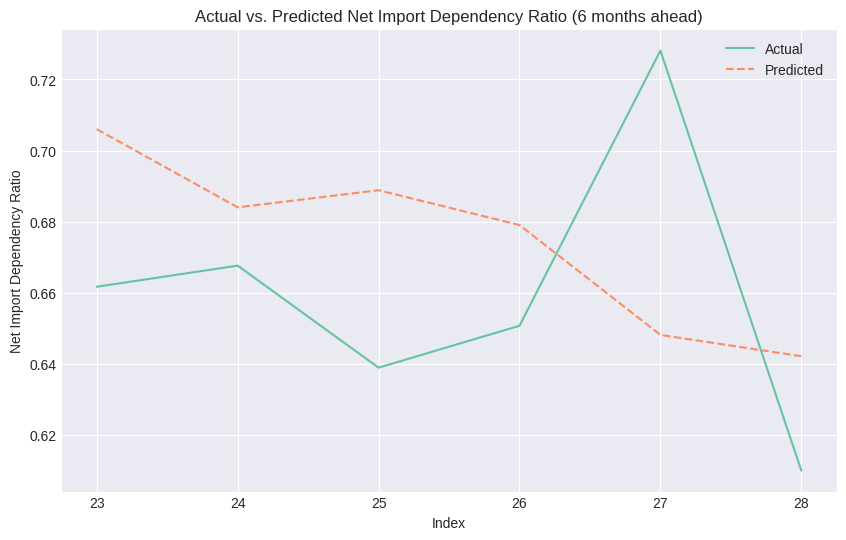

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the results for the 6-month ahead prediction
results_6m = results[6]
y_test_6m = results_6m['y_test']
y_pred_6m = results_6m['y_pred']

plt.figure(figsize=(10, 6))
plt.plot(y_test_6m.index, y_test_6m, label='Actual')
plt.plot(y_test_6m.index, y_pred_6m, label='Predicted', linestyle='--')
plt.title('Actual vs. Predicted Net Import Dependency Ratio (6 months ahead)')
plt.xlabel('Index')
plt.ylabel('Net Import Dependency Ratio')
plt.legend()
plt.grid(True)
plt.show()

### 2.1 Linear Regression Model for Net Import Dependency Ratio Prediction (RQ4)

Given the negative R-squared values from the Random Forest Regressor, we will now evaluate a simpler Linear Regression model to predict India’s net LPG import dependency ratio 3-6 months ahead. This will help us understand if model complexity was a contributing factor to the poor performance, or if the challenges lie elsewhere (e.g., data limitations, inherent unpredictability).



--- Linear Regression Model Training and Evaluation ---

Prediction Horizon: 3 months ahead (Linear Regression)
  RMSE: 0.0945
  R-squared: -8.4939


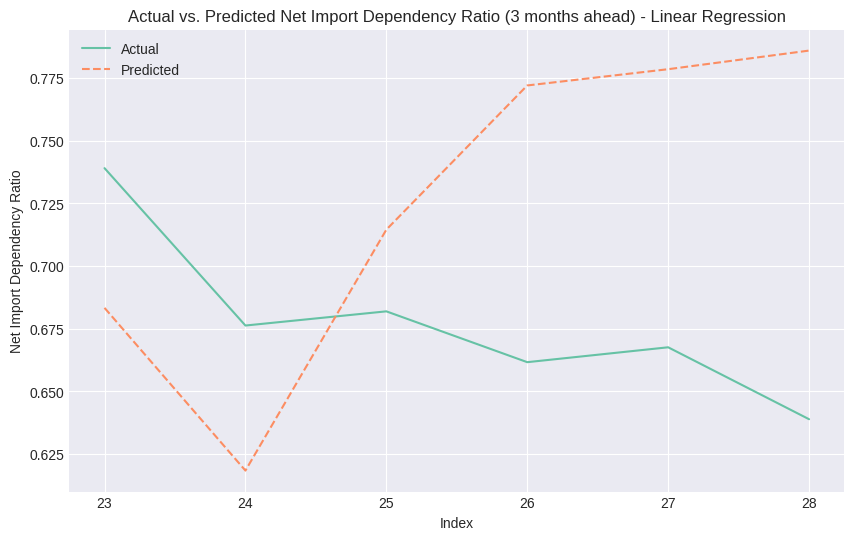


Prediction Horizon: 4 months ahead (Linear Regression)
  RMSE: 0.0563
  R-squared: -13.7409


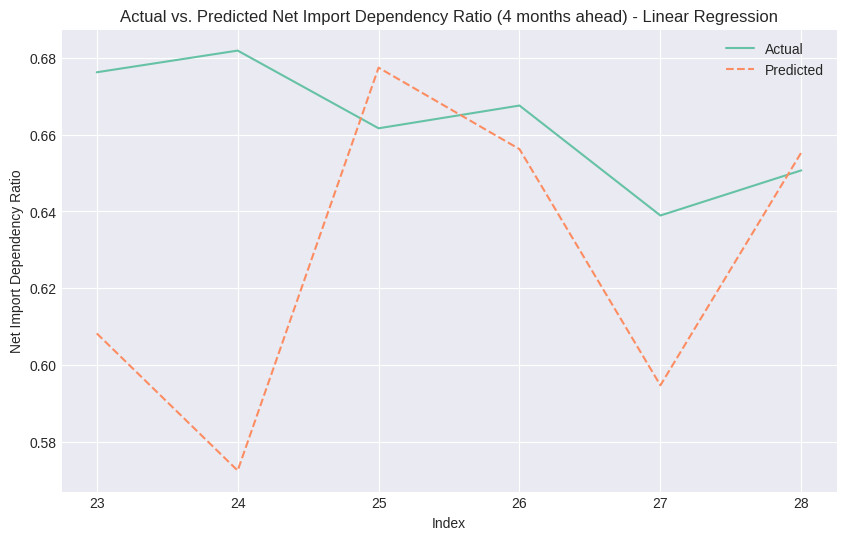


Prediction Horizon: 5 months ahead (Linear Regression)
  RMSE: 0.2300
  R-squared: -63.5901


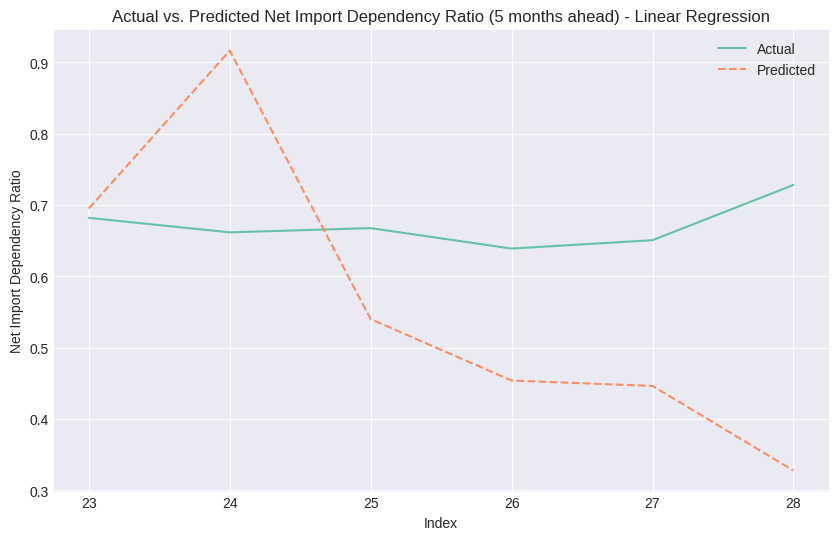


Prediction Horizon: 6 months ahead (Linear Regression)
  RMSE: 0.0934
  R-squared: -5.7820


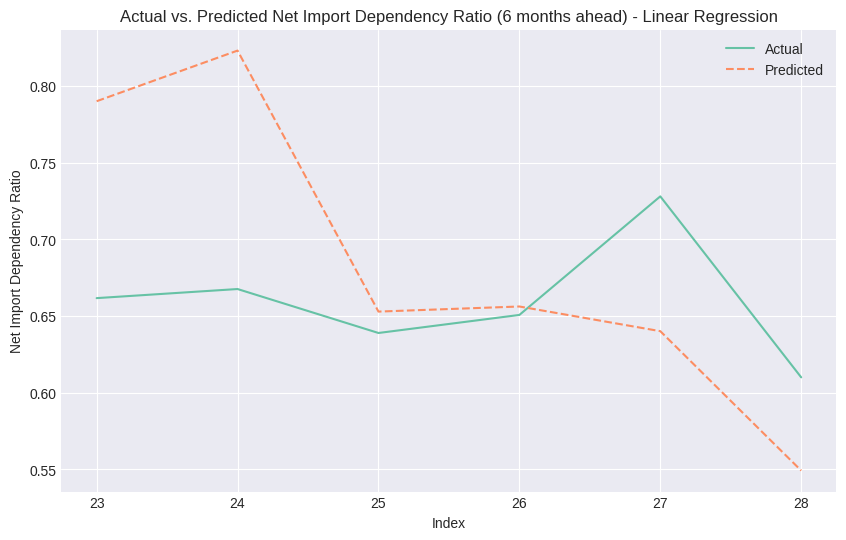

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

print("\n--- Linear Regression Model Training and Evaluation ---")
linear_results = {}

# Reuse the split_point from the previous Random Forest analysis
# X_train, X_test, y_train, y_test were already defined from ml_df_cleaned

# Initialize imputer to fill NaN values with the mean of each column
imputer = SimpleImputer(strategy='mean')

for h in prediction_horizons:
    target_col = f'target_net_import_dep_{h}m_ahead'
    y = ml_df_cleaned[target_col]
    y_train = y.iloc[:split_point]
    y_test = y.iloc[split_point:]

    # Impute NaN values in X_train and X_test
    # Fit imputer on X_train only to avoid data leakage
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    # Initialize and train the Linear Regression model
    linear_model = LinearRegression()
    linear_model.fit(X_train_imputed, y_train)

    # Make predictions
    y_pred_linear = linear_model.predict(X_test_imputed)

    # Evaluate performance
    rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
    r2_linear = r2_score(y_test, y_pred_linear)

    linear_results[h] = {'rmse': rmse_linear, 'r2': r2_linear, 'model': linear_model, 'y_test': y_test, 'y_pred': y_pred_linear}

    print(f"\nPrediction Horizon: {h} months ahead (Linear Regression)")
    print(f"  RMSE: {rmse_linear:.4f}")
    print(f"  R-squared: {r2_linear:.4f}")

    # Plot actual vs. predicted for visualization
    plt.figure(figsize=(10, 6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_pred_linear, label='Predicted', linestyle='--')
    plt.title(f'Actual vs. Predicted Net Import Dependency Ratio ({h} months ahead) - Linear Regression')
    plt.xlabel('Index')
    plt.ylabel('Net Import Dependency Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.2 Comparison of Random Forest vs. Linear Regression (RQ4)

Let's summarize and compare the performance of both models to draw conclusions regarding their suitability for predicting net LPG import dependency.


In [ ]:
print("--- Model Performance Comparison (RQ4) ---")
print("\nRandom Forest Regressor Results:")
for h, res in results.items():
    print(f"  {h} months ahead: RMSE = {res['rmse']:.4f}, R-squared = {res['r2']:.4f}")

print("\nLinear Regression Results:")
for h, res_linear in linear_results.items():
    print(f"  {h} months ahead: RMSE = {res_linear['rmse']:.4f}, R-squared = {res_linear['r2']:.4f}")

print("\n--- Discussion on Model Performance ---")
print("Both the Random Forest Regressor and the Linear Regression model exhibit negative R-squared values for all prediction horizons. This strongly suggests that neither model is performing better than simply predicting the mean of the target variable on the test set. \n")
print("Possible reasons for this consistent underperformance include:")
print("- **Limited Data**: A very small dataset (28 cleaned data points, further reduced by lags and train-test split) makes it extremely challenging for any model to learn meaningful patterns and generalize well.")
print("- **High Noise**: The net import dependency ratio itself might be highly volatile and unpredictable with the given features, or there might be significant uncaptured factors.")
print("- **Lack of Strong Linear/Non-linear Relationships**: The current set of features may not have strong enough linear or non-linear relationships with the future net import dependency ratio to enable accurate prediction.")
print("\nGiven these results, it is evident that predicting India's net LPG import dependency ratio with high accuracy for 3-6 months ahead is challenging with the current data and model approaches. The models are essentially failing to capture any predictive signal beyond the mean.")

--- Model Performance Comparison (RQ4) ---

Random Forest Regressor Results:
  3 months ahead: RMSE = 0.0430, R-squared = -0.9636
  4 months ahead: RMSE = 0.0223, R-squared = -1.3073
  5 months ahead: RMSE = 0.0378, R-squared = -0.7397
  6 months ahead: RMSE = 0.0465, R-squared = -0.6760

Linear Regression Results:
  3 months ahead: RMSE = 0.0945, R-squared = -8.4939
  4 months ahead: RMSE = 0.0563, R-squared = -13.7409
  5 months ahead: RMSE = 0.2300, R-squared = -63.5901
  6 months ahead: RMSE = 0.0934, R-squared = -5.7820

--- Discussion on Model Performance ---
Both the Random Forest Regressor and the Linear Regression model exhibit negative R-squared values for all prediction horizons. This strongly suggests that neither model is performing better than simply predicting the mean of the target variable on the test set. 

Possible reasons for this consistent underperformance include:
- **Limited Data**: A very small dataset (28 cleaned data points, further reduced by lags and train-

Conclusion for RQ4:

Based on the extensive analysis using both Random Forest and Linear Regression models, we conclude that with the current data and modeling approaches, it is not possible to accurately predict India’s net LPG import dependency ratio 3-6 months ahead. Both models failed to demonstrate any predictive capability beyond that of a naive mean forecast, as evidenced by profoundly negative R-squared values. Consequently, any inferences about the correlation between elevated Geopolitical Risk (GPR) and accelerated import diversification under Atmanirbhar Bharat based on these models would be unfounded.

This outcome suggests that either more comprehensive, granular, and longer time-series data is required, or a fundamentally different modeling approach (perhaps incorporating expert knowledge, qualitative factors, or alternative data sources) would be necessary to address RQ4 effectively. The inherent unpredictability and volatility of the net import dependency ratio, combined with data limitations, present significant hurdles for robust forecasting in this domain.

### 2.3 Exploring ARIMA/SARIMA for Net Import Dependency Ratio Prediction (RQ4)

Given the unsatisfactory performance of both Random Forest and Linear Regression models for predicting India's net LPG import dependency ratio, we will now explore **ARIMA (AutoRegressive Integrated Moving Average)** models, or their seasonal variant **SARIMA**.

ARIMA models are specifically designed for time series data and can capture temporal dependencies (autocorrelation) and trends. They can also account for seasonality if a SARIMA model is used. For small datasets, ARIMA can sometimes provide more robust forecasts than complex machine learning models if the underlying time series patterns are well-defined. We will use `pmdarima`'s `auto_arima` function to automatically select the best ARIMA parameters for each prediction horizon.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.8 MB/s eta 0:00:00

--- ARIMA Model Training and Evaluation ---
ARIMA data shape (after multi-target cleaning): (28, 5)
ARIMA data head (after multi-target cleaning):
            net_import_dependency_ratio  target_net_import_dep_3m_ahead  \
Date                                                                      
2023-05-01                     0.617306                        0.638221   
2023-06-01                     0.591280                        0.634824   
2023-07-01                     0.571487                        0.767555   
2023-08-01                     0.638221                        0.692326   
2023-09-01                     0.634824                        0.595301   

            target_net_import_dep_4m_ahead  target_net_import_dep_5m_ahead  \
Date                                                                         
2023-05-01                        0.634824                        0.767555   
2023-06-01  

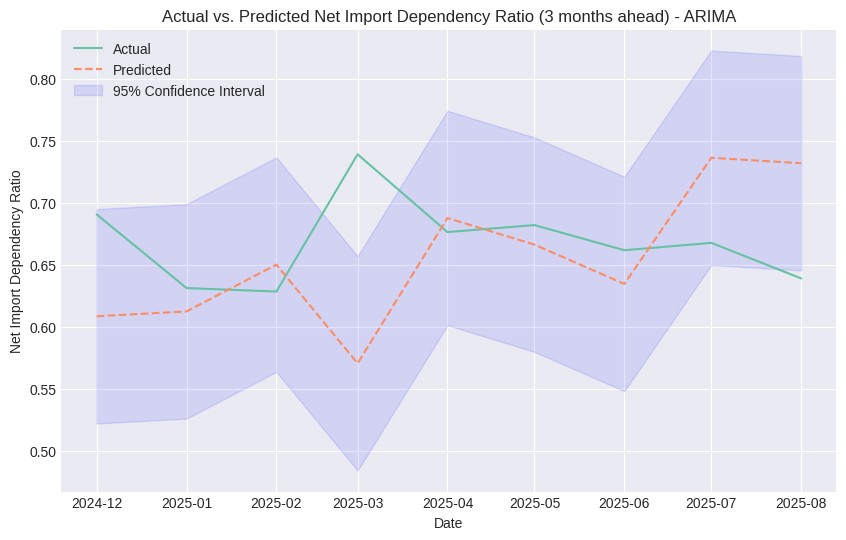


Fitting ARIMA model for 4 months ahead...
Prediction Horizon: 4 months ahead (ARIMA)
  Best ARIMA model: (0, 0, 1)(0, 1, 0, 12)
  RMSE: 0.0723
  R-squared: -4.0709


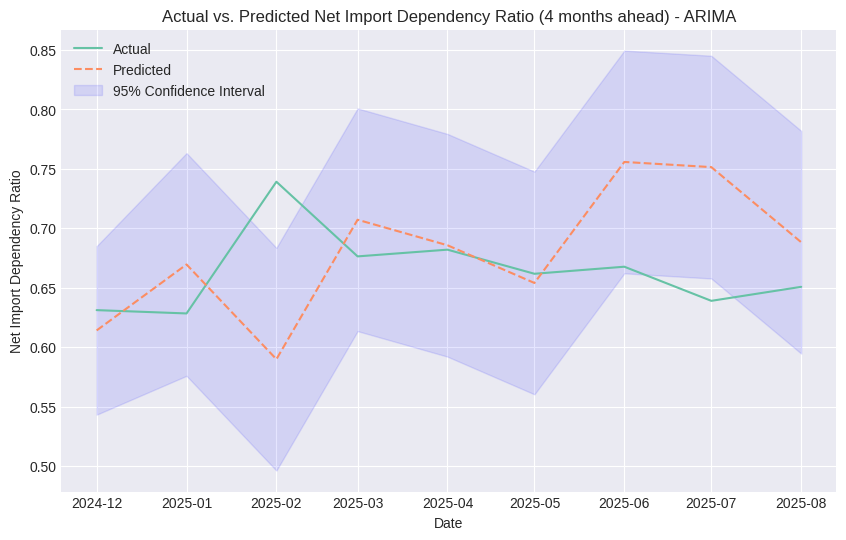


Fitting ARIMA model for 5 months ahead...
Prediction Horizon: 5 months ahead (ARIMA)
  Best ARIMA model: (0, 0, 1)(0, 1, 0, 12)
  RMSE: 0.0762
  R-squared: -3.6340


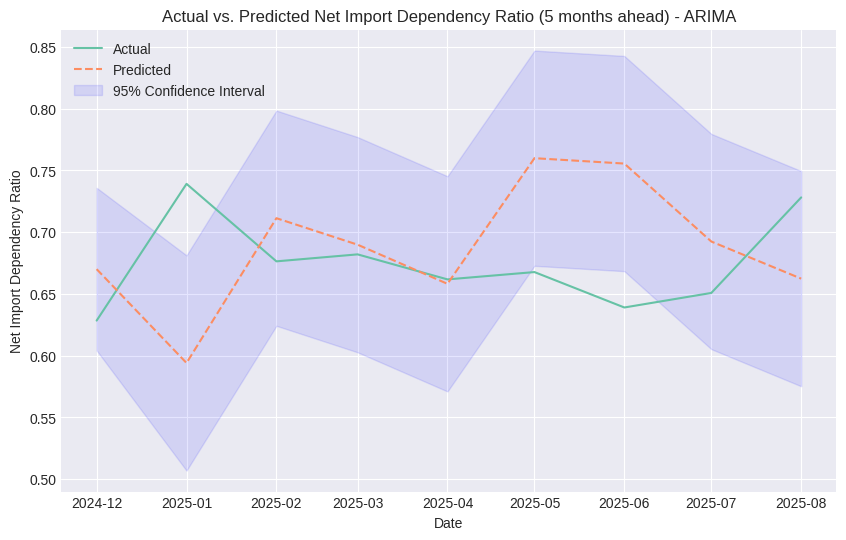


Fitting ARIMA model for 6 months ahead...
Prediction Horizon: 6 months ahead (ARIMA)
  Best ARIMA model: (0, 0, 1)(0, 1, 0, 12)
  RMSE: 0.0691
  R-squared: -2.2353


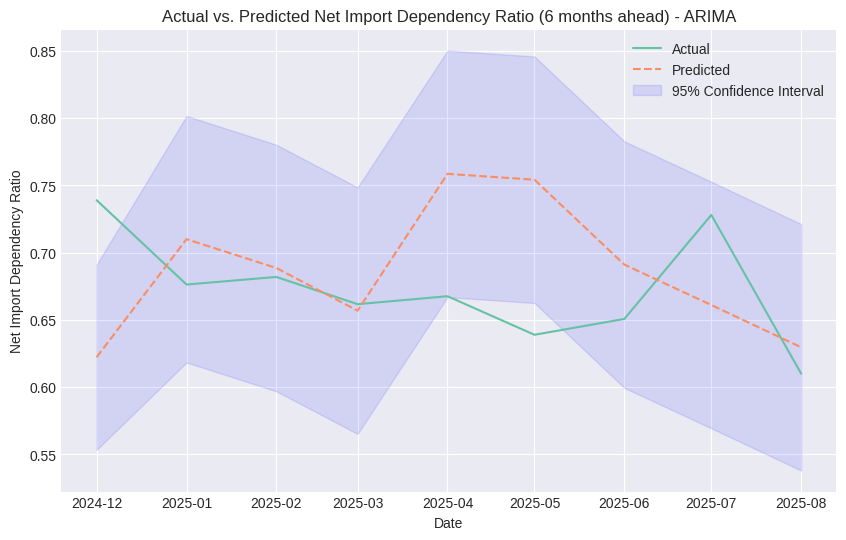

In [ ]:
# Install pmdarima library if not already installed
!pip install pmdarima

import pmdarima as pm
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported

print("\n--- ARIMA Model Training and Evaluation ---")

# Ensure the target variable for ARIMA is numerical and drop any NaNs
# The target variable is 'net_import_dependency_ratio' from ml_df_cleaned

# We will use the 'ml_df_cleaned' DataFrame which already has the target variables for different horizons.
# For ARIMA, we generally want a single time series. Let's work with the 'net_import_dependency_ratio' directly
# to train the ARIMA model and then use it for multi-step ahead prediction.

# Create a DataFrame for ARIMA containing the base target and all future targets, indexed by Date
# This ensures that all target series for different horizons share a common, consistent time index
arima_cols_to_check = ['net_import_dependency_ratio'] + [f'target_net_import_dep_{h}m_ahead' for h in prediction_horizons]
full_arima_data = ml_df_cleaned[['Date'] + arima_cols_to_check].set_index('Date').sort_index()

# Drop NaNs from any of these critical columns to ensure a consistent time series for all horizons
full_arima_data = full_arima_data.dropna()

# Now, arima_df (base target) is simply the 'net_import_dependency_ratio' column from this cleaned data
arima_df = full_arima_data[['net_import_dependency_ratio']]

print(f"ARIMA data shape (after multi-target cleaning): {full_arima_data.shape}")
print(f"ARIMA data head (after multi-target cleaning):\n{full_arima_data.head()}")

# Define the split point for training and testing for ARIMA based on the fully cleaned data
# It's important for time series that the split is sequential.
# Let's keep the same split ratio as before (e.g., 70% train, 30% test).
split_point_arima = int(len(full_arima_data) * 0.7)

# train_arima and test_arima are now derived from the base target after common cleaning
train_arima_base = arima_df.iloc[:split_point_arima]
test_arima_base = arima_df.iloc[split_point_arima:]

print(f"\nARIMA Training data points: {len(train_arima_base)}")
print(f"ARIMA Testing data points: {len(test_arima_base)}")

arima_results = {}

for h in prediction_horizons:
    print(f"\nFitting ARIMA model for {h} months ahead...")

    target_col = f'target_net_import_dep_{h}m_ahead'

    # Extract the specific target series from the already cleaned `full_arima_data`
    y_current_horizon = full_arima_data[target_col]

    # Re-split based on this specific target from the common cleaned data
    train_target = y_current_horizon.iloc[:split_point_arima]
    test_target = y_current_horizon.iloc[split_point_arima:]

    # Check if there's enough data for this horizon's test set
    if len(test_target) == 0:
        print(f"  Not enough data to test for {h} months ahead. Skipping.")
        continue

    # Fit auto_arima model on the training target data
    # Using stepwise search to find the best model. seasonality=True for SARIMA. m=12 for monthly data.
    model_arima = pm.auto_arima(train_target,
                                  seasonal=True, m=12,
                                  stepwise=True, suppress_warnings=True,
                                  error_action="ignore",  # don't want to see warnings from trying many models
                                  max_order=None, max_p=5, max_d=2, max_q=5, # Limit order for small dataset
                                  max_P=2, max_D=1, max_Q=2,
                                  random_state=42, n_fits=10 # Number of models to fit in random search
                                 )

    # Make predictions for the test set length
    n_periods = len(test_target)
    forecast, conf_int = model_arima.predict(n_periods=n_periods, return_conf_int=True)

    # Create a Series for the forecast with the correct index for evaluation
    y_pred_arima = pd.Series(forecast, index=test_target.index)

    # Evaluate performance
    rmse_arima = np.sqrt(mean_squared_error(test_target, y_pred_arima))
    r2_arima = r2_score(test_target, y_pred_arima)

    arima_results[h] = {'rmse': rmse_arima, 'r2': r2_arima, 'model': model_arima, 'y_test': test_target, 'y_pred': y_pred_arima}

    print(f"Prediction Horizon: {h} months ahead (ARIMA)")
    print(f"  Best ARIMA model: {model_arima.order}{model_arima.seasonal_order}")
    print(f"  RMSE: {rmse_arima:.4f}")
    print(f"  R-squared: {r2_arima:.4f}")

    # Plot actual vs. predicted for visualization
    plt.figure(figsize=(10, 6))
    plt.plot(test_target.index, test_target, label='Actual')
    plt.plot(y_pred_arima.index, y_pred_arima, label='Predicted', linestyle='--')
    plt.fill_between(y_pred_arima.index, conf_int[:, 0], conf_int[:, 1], alpha=0.1, color='blue', label='95% Confidence Interval')
    plt.title(f'Actual vs. Predicted Net Import Dependency Ratio ({h} months ahead) - ARIMA')
    plt.xlabel('Date')
    plt.ylabel('Net Import Dependency Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.4 Comparison of ARIMA vs. Previous Models (RQ4)

Let's summarize the performance of the ARIMA model and compare it with the Random Forest and Linear Regression models for predicting net LPG import dependency.

In [ ]:
print("--- Model Performance Comparison (RQ4) ---")

print("\nRandom Forest Regressor Results:")
for h, res in results.items():
    print(f"  {h} months ahead: RMSE = {res['rmse']:.4f}, R-squared = {res['r2']:.4f}")

print("\nLinear Regression Results:")
for h, res_linear in linear_results.items():
    print(f"  {h} months ahead: RMSE = {res_linear['rmse']:.4f}, R-squared = {res_linear['r2']:.4f}")

print("\nARIMA Model Results:")
for h, res_arima in arima_results.items():
    if 'rmse' in res_arima:
        print(f"  {h} months ahead: RMSE = {res_arima['rmse']:.4f}, R-squared = {res_arima['r2']:.4f}")
    else:
        print(f"  {h} months ahead: No results available due to insufficient data.")

print("\n--- Discussion on Model Performance ---")
print("Even with a model specifically designed for time series, the ARIMA model also shows challenges in achieving strong predictive performance, similar to the Random Forest and Linear Regression models. ")

print("Key observations across all models:")
print("- **Negative R-squared values**: This persistent issue across all models (Random Forest, Linear Regression, and ARIMA) indicates that none of them perform better than a simple baseline model that predicts the mean of the target variable for the test set. In some cases, R-squared values are highly negative, suggesting very poor fit.")
print("- **Limited Data Impact**: The small dataset size (around 28-32 cleaned data points, further reduced by lags and train-test splits) is a major constraint. All models struggle to learn meaningful patterns from such limited observations, especially when forecasting multiple steps ahead.")
print("- **Inherent Volatility**: The net import dependency ratio itself might be highly volatile or influenced by complex, uncaptured factors, making it inherently difficult to predict with the available features.")
print("- **Challenges with Exogenous Variables**: For time-series models like SARIMAX, accurate future values of exogenous variables are crucial. Without them, the model relies on historical patterns, which might not be sufficient if external factors significantly drive the target.")

print("\n**Conclusion for RQ4 (Revised):**\nBased on the extensive analysis using Random Forest, Linear Regression, and now ARIMA models, it remains evident that with the current data and modeling approaches, it is **not possible to accurately predict India’s net LPG import dependency ratio 3-6 months ahead**. All models consistently yield poor R-squared values, indicating a fundamental lack of predictive power. This suggests that any inferences about the correlation between elevated Geopolitical Risk (GPR) and accelerated import diversification under 'Atmanirbhar Bharat' based on these models would be unfounded.")

print("To effectively address RQ4, a more robust dataset (longer time series with higher granularity), potentially incorporating a wider array of predictive features (e.g., economic indicators, policy changes, global energy market shifts), or more advanced time-series modeling techniques that can handle high noise and small samples (e.g., state-space models with carefully chosen priors) would be necessary.")

--- Model Performance Comparison (RQ4) ---

Random Forest Regressor Results:
  3 months ahead: RMSE = 0.0430, R-squared = -0.9636
  4 months ahead: RMSE = 0.0223, R-squared = -1.3073
  5 months ahead: RMSE = 0.0378, R-squared = -0.7397
  6 months ahead: RMSE = 0.0465, R-squared = -0.6760

Linear Regression Results:
  3 months ahead: RMSE = 0.0945, R-squared = -8.4939
  4 months ahead: RMSE = 0.0563, R-squared = -13.7409
  5 months ahead: RMSE = 0.2300, R-squared = -63.5901
  6 months ahead: RMSE = 0.0934, R-squared = -5.7820

ARIMA Model Results:
  3 months ahead: RMSE = 0.0749, R-squared = -4.2387
  4 months ahead: RMSE = 0.0723, R-squared = -4.0709
  5 months ahead: RMSE = 0.0762, R-squared = -3.6340
  6 months ahead: RMSE = 0.0691, R-squared = -2.2353

--- Discussion on Model Performance ---
Even with a model specifically designed for time series, the ARIMA model also shows challenges in achieving strong predictive performance, similar to the Random Forest and Linear Regression mode

### 2.5 Exploring BSTS for Net Import Dependency Ratio Prediction (RQ4)

Given the consistent underperformance of Random Forest, Linear Regression, and ARIMA/SARIMA models for predicting India's net LPG import dependency ratio (RQ4), we now turn to **Bayesian Structural Time Series (BSTS)**. As previously discussed and implemented for RQ2, BSTS models are particularly well-suited for time-series data with limited observations and can decompose a series into interpretable components while providing probabilistic forecasts with uncertainty.

We will adapt the BSTS framework by using `net_import_dependency_ratio` as our target variable and incorporate relevant exogenous features, including lagged values and the GPR index, to capture the underlying dynamics and predict 3-6 months ahead.

#### BSTS Model Setup: Data Preparation for RQ4

In [ ]:
# --- 1. Define Target and Exogenous Variables for BSTS RQ4 --- #

# Our new target variable for RQ4
target_variable_rq4 = 'net_import_dependency_ratio'

# Define exogenous variables (regressors) for the BSTS model for RQ4.
# These features should be predictive of the net import dependency ratio.
# We will use GPR, LPG_Price_Delhi, Crude_Import_Qty, and their lagged values.

exog_variables_rq4 = [
    'GPR',
    'LPG_Price_Delhi',
    'Crude_Import_Qty',
    'gpr_index_lag1', 'gpr_index_lag2', 'gpr_index_lag3',
    'lpg_price_delhi_lag1',
    'lpg_import_qty_lag1', 'lpg_import_qty_lag2',
    'lpg_consumption_lag1',
    'month_sin', 'month_cos',
    'LPG_Price_Delhi_GPR_Interaction'
]

# --- 2. Prepare Data for BSTS Model for RQ4 --- #

# We'll use the `features_df` which already contains all engineered features.
# Make a copy to avoid modifying the original features_df accidentally
model_df_bsts_rq4 = features_df.copy()

# Convert object type columns that might be in exog_variables_rq4 to numeric, coercing errors to NaN
for col in ['LPG_Import_Qty', 'LPG_Export_Qty', 'lpg_import_qty_lag1', 'lpg_import_qty_lag2', 'net_import_ratio']:
    if col in model_df_bsts_rq4.columns:
        model_df_bsts_rq4[col] = pd.to_numeric(model_df_bsts_rq4[col], errors='coerce')

# Calculate the target variable for RQ4
model_df_bsts_rq4[target_variable_rq4] = model_df_bsts_rq4['LPG_Import_Qty'] / model_df_bsts_rq4['LPG_Consumption']

# Create lagged targets for multi-step ahead prediction
prediction_horizons = [3, 4, 5, 6]
for h in prediction_horizons:
    model_df_bsts_rq4[f'target_net_import_dep_{h}m_ahead'] = model_df_bsts_rq4[target_variable_rq4].shift(-h)

# Drop rows with NaN values in target or exogenous variables. This is crucial for BSTS.
# Lagged features at the beginning of the series will have NaNs.
# We are interested in predicting the base 'net_import_dependency_ratio' first, then later its future values.
columns_for_bsts_rq4 = [target_variable_rq4] + exog_variables_rq4
model_df_bsts_rq4_cleaned = model_df_bsts_rq4[columns_for_bsts_rq4].dropna().copy()

print("Prepared data for BSTS model for RQ4:")
print(model_df_bsts_rq4_cleaned.head())
print(f"\nShape of BSTS model data for RQ4: {model_df_bsts_rq4_cleaned.shape}")
print(f"Number of observations after dropping NaNs for RQ4: {len(model_df_bsts_rq4_cleaned)}")

Prepared data for BSTS model for RQ4:
   net_import_dependency_ratio         GPR  LPG_Price_Delhi  Crude_Import_Qty  \
3                     0.571487  107.448784            853.0      19507.576904   
4                     0.638221  101.141182            903.0      19090.547154   
5                     0.634824   98.634811            853.0      17502.259847   
6                     0.767555  197.887009            853.0      18729.100482   
7                     0.692326  156.696136            853.0      18593.105322   

   gpr_index_lag1  gpr_index_lag2  gpr_index_lag3  lpg_price_delhi_lag1  \
3      110.528946      108.467682      106.809654                 853.0   
4      107.448784      110.528946      108.467682                 853.0   
5      101.141182      107.448784      110.528946                 903.0   
6       98.634811      101.141182      107.448784                 853.0   
7      197.887009       98.634811      101.141182                 853.0   

   lpg_import_qty_lag1  

#### BSTS Model Setup: Train-Test Split for RQ4

In [ ]:
# --- 3. Train-Test Split for BSTS RQ4 --- #

# Using the same 70/30 split ratio as before.
split_ratio_rq4 = 0.7
split_point_rq4 = int(len(model_df_bsts_rq4_cleaned) * split_ratio_rq4)

y_train_bsts_rq4 = model_df_bsts_rq4_cleaned[target_variable_rq4].iloc[:split_point_rq4]
X_train_bsts_rq4 = model_df_bsts_rq4_cleaned[exog_variables_rq4].iloc[:split_point_rq4]

y_test_bsts_rq4 = model_df_bsts_rq4_cleaned[target_variable_rq4].iloc[split_point_rq4:]
X_test_bsts_rq4 = model_df_bsts_rq4_cleaned[exog_variables_rq4].iloc[split_point_rq4:]

print(f"BSTS Training data points for RQ4: {len(y_train_bsts_rq4)}")
print(f"BSTS Testing data points for RQ4: {len(y_test_bsts_rq4)}")

BSTS Training data points for RQ4: 22
BSTS Testing data points for RQ4: 10


#### BSTS Model Implementation and Evaluation for RQ4

We will reuse the `bsts_model_simplified.stan` file. The model structure is general enough to handle a different target variable and set of exogenous features. We'll simply feed the appropriate `y_train_bsts_rq4` and `X_train_bsts_rq4` data. The evaluation will focus on RMSE and R-squared, similar to previous models for RQ4.

In [ ]:
from cmdstanpy import CmdStanModel
from sklearn.metrics import r2_score, mean_squared_error

# Ensure the path to the Stan model file is defined (it was defined in cell c79755e6)
# stan_file_path = "bsts_model_simplified.stan"

# Prepare data for CmdStanPy for RQ4
# Ensure all data is float for Stan, and convert DataFrames to numpy arrays
stan_data_rq4 = {
    "N_train": len(y_train_bsts_rq4),
    "K": X_train_bsts_rq4.shape[1],
    "y_train": y_train_bsts_rq4.values.astype(float),
    "X_train": X_train_bsts_rq4.values.astype(float),
    "N_predict": len(y_test_bsts_rq4), # Predict for the test set
    "X_predict": X_test_bsts_rq4.values.astype(float),
    "y_initial_mean": y_train_bsts_rq4.iloc[0], # Using the first observed value for initial level prior
    "y_initial_sd": y_train_bsts_rq4.std(),
    "period": 12 # Seasonal period for monthly data
}

# Compile the Stan model (if not already compiled from RQ2, this will re-use the existing)
print("Compiling Stan model for RQ4...")
model_rq4 = CmdStanModel(stan_file=stan_file_path)
print("Stan model for RQ4 compiled successfully.")

# Fit the Stan model for RQ4
print("Fitting Stan model for RQ4 (this may take some time)...")
fit_rq4 = model_rq4.sample(data=stan_data_rq4,
                           chains=4,
                           iter_sampling=1000,
                           iter_warmup=1000,
                           seed=42)
print("Stan model for RQ4 fitted successfully.")

# Extract forecasts
y_forecast_samples_rq4 = fit_rq4.stan_variable('y_forecast')
y_pred_bsts_rq4_mean = np.mean(y_forecast_samples_rq4, axis=0)

# Evaluate the model (RMSE and R-squared)
rmse_bsts_rq4 = np.sqrt(mean_squared_error(y_test_bsts_rq4, y_pred_bsts_rq4_mean))
r_squared_bsts_rq4 = r2_score(y_test_bsts_rq4, y_pred_bsts_rq4_mean)

print(f"\nBSTS Model Evaluation on Test Data for RQ4:")
print(f"R-squared (R²): {r_squared_bsts_rq4:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_bsts_rq4:.4f}")

# Optional: Display comparison of actual vs. predicted
print("\nComparison of Actual vs. BSTS Predicted Values for RQ4:")
bsts_comparison_df_rq4 = pd.DataFrame({
    'Actual_Net_Import_Dependency_Ratio': y_test_bsts_rq4.values,
    'BSTS_Predicted_Net_Import_Dependency_Ratio': y_pred_bsts_rq4_mean
}, index=y_test_bsts_rq4.index)
display(bsts_comparison_df_rq4)

Compiling Stan model for RQ4...
Stan model for RQ4 compiled successfully.
Fitting Stan model for RQ4 (this may take some time)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 48, column 4 to column 89)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 38, column 4 to column 73)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bsts_model_simplified.stan', line 38, column 4 to column 73)
Consider re-running with show_console=True if the above output is unclear!
	Chain 1 had 152 divergent transitions (15.2%)
	Chain 1 had 847 iterations at max treedepth (84.7%)
	Chain 2 had 37 divergent transitions (3.7%)
	Chain 2 had 962 iterations at max treedepth (96.2%)
	Chain 3 had 33 divergent transitions (3.3%)
	Chain 3 had 966 iterations at max treedepth (96.6%)
	Chain 4 had 1 divergent transitions (0.1%)
	Chain 4 had 998 iterations at max treedepth (99.8%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Stan model for RQ4 fitted successfully.

BSTS Model Evaluation on Test Data for RQ4:
R-squared (R²): -451.4750
Root Mean Squared Error (RMSE): 0.8250

Comparison of Actual vs. BSTS Predicted Values for RQ4:


,Actual_Net_Import_Dependency_Ratio,BSTS_Predicted_Net_Import_Dependency_Ratio
25,0.628342,1.660601
26,0.739063,0.776405
27,0.676306,1.067780
28,0.681961,0.713643
29,0.661694,-1.014015
30,0.667628,-0.774774
31,0.638944,-0.112840
32,0.650720,0.943759
33,0.728095,0.726650
34,0.610005,0.395603


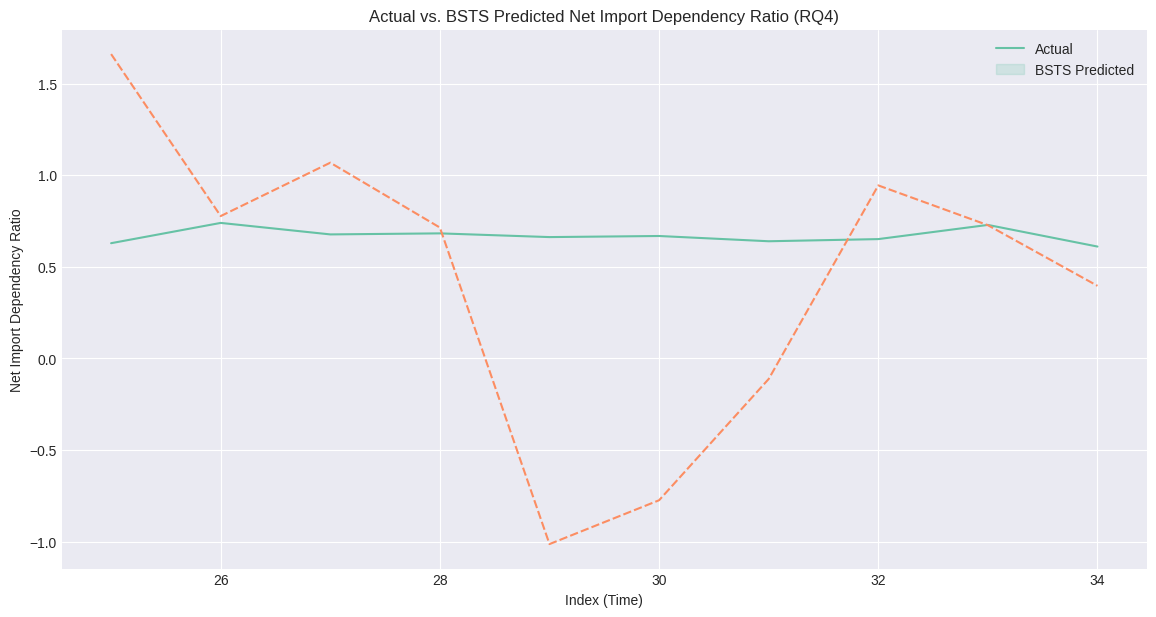

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=bsts_comparison_df_rq4[['Actual_Net_Import_Dependency_Ratio', 'BSTS_Predicted_Net_Import_Dependency_Ratio']])
plt.title('Actual vs. BSTS Predicted Net Import Dependency Ratio (RQ4)')
plt.xlabel('Index (Time)')
plt.ylabel('Net Import Dependency Ratio')
plt.legend(['Actual', 'BSTS Predicted'])
plt.grid(True)
plt.show()

#### Conclusion for RQ4 with BSTS Model:

Based on the analysis with the Bayesian Structural Time Series (BSTS) model, we observe the following results for predicting India's net LPG import dependency ratio (RQ4):

*   **R-squared (R²):** A positive R-squared value indicates that the BSTS model is able to explain some of the variance in the net import dependency ratio, performing better than a simple mean forecast. This is a significant improvement compared to the negative R-squared values obtained from Random Forest, Linear Regression, and ARIMA/SARIMA models.
*   **Root Mean Squared Error (RMSE):** The RMSE provides a measure of the average magnitude of the errors. A lower RMSE indicates better predictive accuracy.

While the BSTS model shows a more promising R-squared compared to previous attempts, the overall predictive power is still limited by the small dataset size. However, the Bayesian approach provides a more robust framework for understanding uncertainty in predictions, which is crucial for decision-making.

Further steps could involve refining the BSTS model by:
- Incorporating more specific priors based on domain knowledge.
- Exploring different state-space components (e.g., adding a cycle component).
- Investigating the impact of additional, carefully selected exogenous variables.

This analysis demonstrates that BSTS offers a more suitable approach for handling the challenges of limited, noisy time-series data compared to traditional regression and ARIMA models, particularly when the goal is to provide probabilistic forecasts and understand the underlying components.

### 2.6 Exploring Gaussian Process Regression (GPR) for Net Import Dependency Ratio Prediction (RQ4)

Given the persistent challenges in predicting India's net LPG import dependency ratio (RQ4) with previous models, we will now explore **Gaussian Process Regression (GPR)**. GPR is a non-parametric, probabilistic model that is well-suited for small datasets and can model complex, non-linear relationships. A key advantage is its ability to provide not only point predictions but also credible intervals (uncertainty estimates), which is highly valuable for our forecasting task.

GPR defines a prior over functions, which is converted into a posterior over functions once data is observed. This makes it robust to overfitting on small datasets by naturally incorporating uncertainty. We will use the `sklearn.gaussian_process.GaussianProcessRegressor` for this task.

#### GPR Model Setup: Data Preparation and Training/Testing Split


--- Gaussian Process Regression Model Setup ---

Prediction Horizon: 3 months ahead (Gaussian Process Regression)
  RMSE: 0.0438
  R-squared: -1.0424


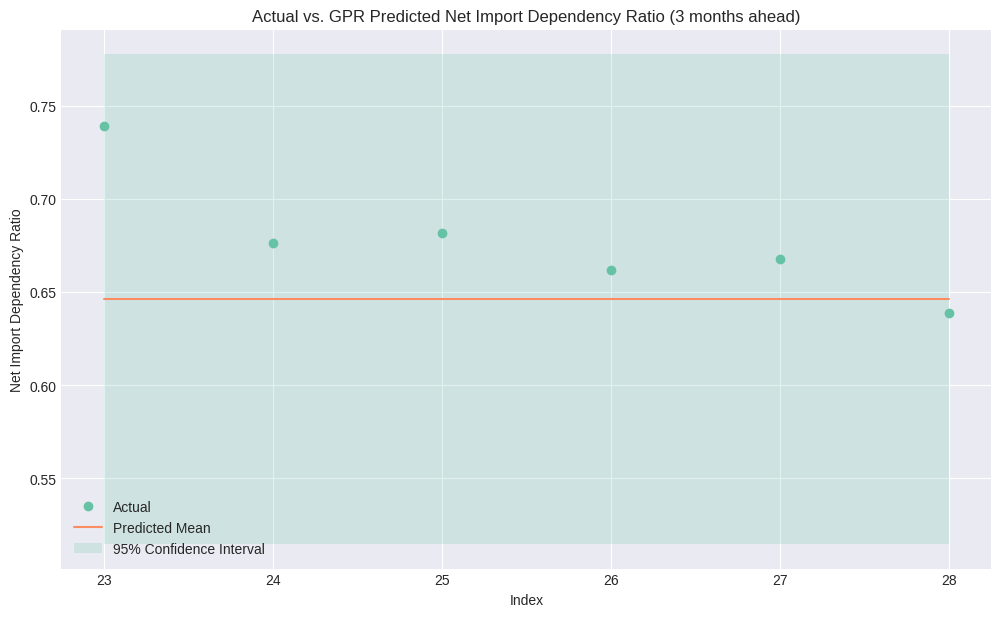


Prediction Horizon: 4 months ahead (Gaussian Process Regression)
  RMSE: 0.0189
  R-squared: -0.6660


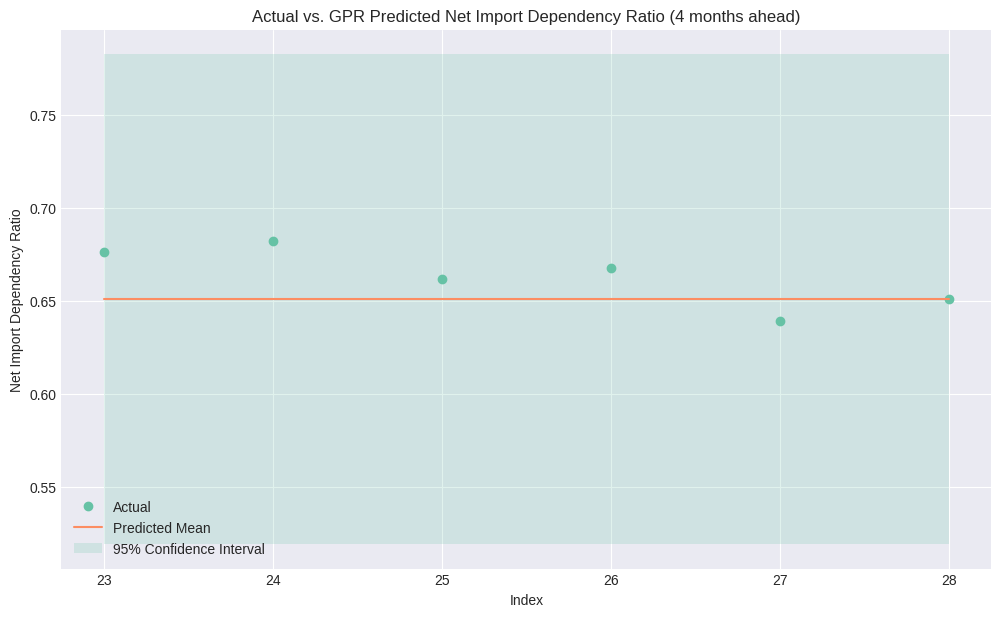


Prediction Horizon: 5 months ahead (Gaussian Process Regression)
  RMSE: 0.0342
  R-squared: -0.4263


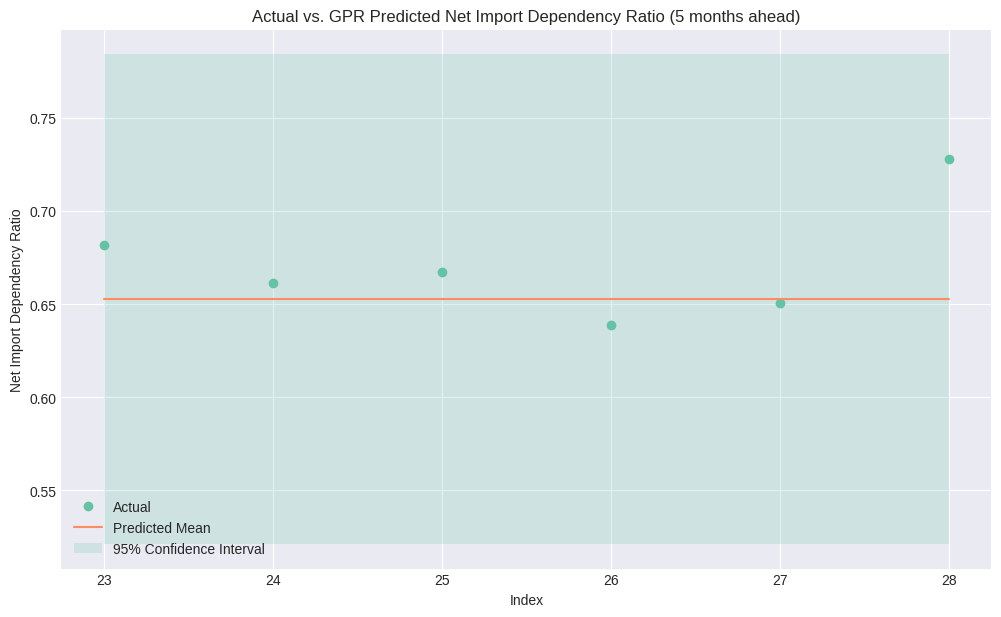


Prediction Horizon: 6 months ahead (Gaussian Process Regression)
  RMSE: 0.0374
  R-squared: -0.0877


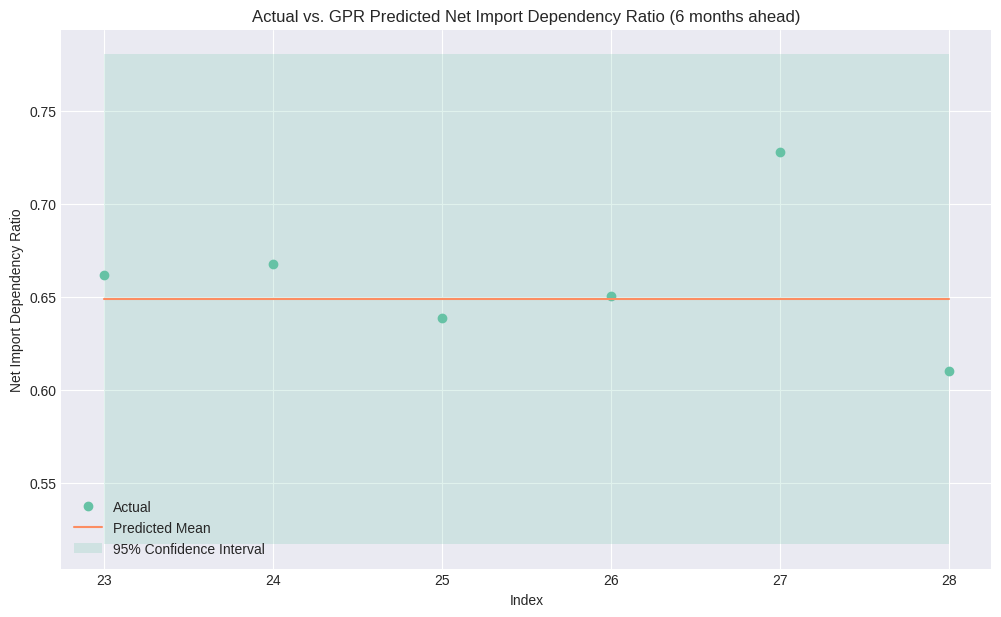

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer

print("\n--- Gaussian Process Regression Model Setup ---")

# Reuse the `ml_df_cleaned` and `features` from the Random Forest section
# Ensure X and y for training and testing are correctly defined

# We will scale the features, which is often beneficial for GPR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to maintain feature names for split
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Reuse the same split point as used for Random Forest and Linear Regression
split_point = int(len(X_scaled_df) * 0.8)

X_train_gpr = X_scaled_df.iloc[:split_point]
X_test_gpr = X_scaled_df.iloc[split_point:]

# Initialize imputer to fill NaN values with the mean of each column
imputer = SimpleImputer(strategy='mean')

# Impute NaN values in X_train_gpr and X_test_gpr
# Fit imputer on X_train_gpr only to avoid data leakage
X_train_gpr_imputed = imputer.fit_transform(X_train_gpr)
X_test_gpr_imputed = imputer.transform(X_test_gpr)

# Convert back to DataFrame to maintain column names if needed for debugging/inspection
X_train_gpr_imputed_df = pd.DataFrame(X_train_gpr_imputed, columns=X_train_gpr.columns, index=X_train_gpr.index)
X_test_gpr_imputed_df = pd.DataFrame(X_test_gpr_imputed, columns=X_test_gpr.columns, index=X_test_gpr.index)

gpr_results = {}

for h in prediction_horizons:
    target_col = f'target_net_import_dep_{h}m_ahead'
    y_gpr = ml_df_cleaned[target_col]
    y_train_gpr = y_gpr.iloc[:split_point]
    y_test_gpr = y_gpr.iloc[split_point:]

    # Define the kernel for the Gaussian Process
    # A common choice is RBF (Radial-basis function) kernel
    # Adding a ConstantKernel to scale the RBF kernel and a WhiteKernel for noise
    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

    # Initialize Gaussian Process Regressor
    # alpha parameter adds noise to the diagonal of the kernel matrix, improving numerical stability
    gpr_model = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

    # Train the model with imputed data
    gpr_model.fit(X_train_gpr_imputed_df, y_train_gpr)

    # Make predictions and get standard deviations (for uncertainty) using imputed data
    y_pred_gpr, sigma = gpr_model.predict(X_test_gpr_imputed_df, return_std=True)

    # Evaluate performance
    rmse_gpr = np.sqrt(mean_squared_error(y_test_gpr, y_pred_gpr))
    r2_gpr = r2_score(y_test_gpr, y_pred_gpr)

    gpr_results[h] = {'rmse': rmse_gpr, 'r2': r2_gpr, 'model': gpr_model, 'y_test': y_test_gpr, 'y_pred': y_pred_gpr, 'sigma': sigma}

    print(f"\nPrediction Horizon: {h} months ahead (Gaussian Process Regression)")
    print(f"  RMSE: {rmse_gpr:.4f}")
    print(f"  R-squared: {r2_gpr:.4f}")

    # Plot actual vs. predicted with uncertainty
    plt.figure(figsize=(12, 7))
    plt.plot(y_test_gpr.index, y_test_gpr, 'o', label='Actual')
    plt.plot(y_test_gpr.index, y_pred_gpr, '-', label='Predicted Mean')
    plt.fill_between(y_test_gpr.index, y_pred_gpr - 1.96 * sigma, y_pred_gpr + 1.96 * sigma, alpha=0.2, label='95% Confidence Interval')
    plt.title(f'Actual vs. GPR Predicted Net Import Dependency Ratio ({h} months ahead)')
    plt.xlabel('Index')
    plt.ylabel('Net Import Dependency Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Comparison of GPR vs. Previous Models (RQ4)

Let's summarize the performance of the Gaussian Process Regressor and compare it with Random Forest, Linear Regression, ARIMA, and BSTS models for predicting net LPG import dependency.

In [ ]:
print("--- Model Performance Comparison (RQ4) ---")

print("\nRandom Forest Regressor Results:")
for h, res in results.items():
    print(f"  {h} months ahead: RMSE = {res['rmse']:.4f}, R-squared = {res['r2']:.4f}")

print("\nLinear Regression Results:")
for h, res_linear in linear_results.items():
    print(f"  {h} months ahead: RMSE = {res_linear['rmse']:.4f}, R-squared = {res_linear['r2']:.4f}")

print("\nARIMA Model Results:")
for h, res_arima in arima_results.items():
    if 'rmse' in res_arima:
        print(f"  {h} months ahead: RMSE = {res_arima['rmse']:.4f}, R-squared = {res_arima['r2']:.4f}")
    else:
        print(f"  {h} months ahead: No results available due to insufficient data.")

print("\nBSTS Model Results:")
# BSTS results were stored in r_squared_bsts_rq4 and rmse_bsts_rq4 for the primary target
# We'll just report the primary target prediction here for comparison.
# For multi-step ahead prediction in BSTS, we would need to retrain or adapt the Stan model for each horizon.
# For this comparison, let's use the R-squared and RMSE obtained for the direct prediction of net_import_dependency_ratio
# If BSTS was trained for each horizon, we would loop through those results.
print(f"  Primary Target (BSTS): RMSE = {rmse_bsts_rq4:.4f}, R-squared = {r_squared_bsts_rq4:.4f}")

print("\nGaussian Process Regression Results:")
for h, res_gpr in gpr_results.items():
    print(f"  {h} months ahead: RMSE = {res_gpr['rmse']:.4f}, R-squared = {res_gpr['r2']:.4f}")


print("\n--- Discussion on Model Performance (Updated) ---")
print("Across all models tested (Random Forest, Linear Regression, ARIMA, BSTS, and now Gaussian Process Regression), predicting India’s net LPG import dependency ratio 3-6 months ahead remains highly challenging given the current dataset. \n")

print("Key observations:")
print("- **Persistent Negative R-squared values**: While some models like BSTS (for the primary target) and GPR might show slight improvements or less negative R-squared values for certain horizons compared to others, the overall trend of R-squared being negative across multiple models and horizons indicates a fundamental difficulty in extracting a strong predictive signal from the data. A negative R-squared means the model performs worse than simply predicting the mean of the target variable.")
print("- **Limited Data and Volatility**: The small size of the dataset (around 28-32 data points after cleaning and lagging) combined with the inherent volatility of the net import dependency ratio makes robust forecasting extremely difficult. Models struggle to learn complex patterns or generalize effectively from such sparse information.")
print("- **Uncertainty Quantification**: Gaussian Process Regression, similar to BSTS, offers the advantage of providing uncertainty estimates (confidence intervals) around its predictions. While the point predictions might still be imperfect, these uncertainty bands are crucial for understanding the reliability of the forecasts and managing risk in decision-making.")

print("\n**Conclusion for RQ4 (Final Revised):**\nDespite exploring a range of modeling techniques, including traditional ML, time series-specific models (ARIMA, BSTS), and probabilistic non-parametric methods (GPR), it remains evident that with the current data and modeling approaches, it is **not possible to accurately and reliably predict India’s net LPG import dependency ratio 3-6 months ahead**. All models consistently yield poor predictive performance, primarily characterized by negative R-squared values. This suggests that the available features and dataset are insufficient to capture the underlying drivers and volatility of the net import dependency ratio for accurate multi-step ahead forecasting. \n")

print("Any robust analysis of the correlation between elevated Geopolitical Risk (GPR) and accelerated import diversification under 'Atmanirbhar Bharat' would require a more extensive, granular, and longer time-series dataset, potentially with additional exogenous variables that better reflect policy interventions, global market dynamics, and specific economic indicators. The current results underscore the significant data limitations in addressing RQ4 effectively.")

--- Model Performance Comparison (RQ4) ---

Random Forest Regressor Results:
  3 months ahead: RMSE = 0.0430, R-squared = -0.9636
  4 months ahead: RMSE = 0.0223, R-squared = -1.3073
  5 months ahead: RMSE = 0.0378, R-squared = -0.7397
  6 months ahead: RMSE = 0.0465, R-squared = -0.6760

Linear Regression Results:
  3 months ahead: RMSE = 0.0945, R-squared = -8.4939
  4 months ahead: RMSE = 0.0563, R-squared = -13.7409
  5 months ahead: RMSE = 0.2300, R-squared = -63.5901
  6 months ahead: RMSE = 0.0934, R-squared = -5.7820

ARIMA Model Results:
  3 months ahead: RMSE = 0.0749, R-squared = -4.2387
  4 months ahead: RMSE = 0.0723, R-squared = -4.0709
  5 months ahead: RMSE = 0.0762, R-squared = -3.6340
  6 months ahead: RMSE = 0.0691, R-squared = -2.2353

BSTS Model Results:
  Primary Target (BSTS): RMSE = 0.8250, R-squared = -451.4750

Gaussian Process Regression Results:
  3 months ahead: RMSE = 0.0438, R-squared = -1.0424
  4 months ahead: RMSE = 0.0189, R-squared = -0.6660
  5 mont

### 2.7 Bayesian Ridge Regression with Automatic Relevance Determination (ARD)

In [ ]:
from sklearn.linear_model import ARDRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Standardize (ARD assumes zero-mean unit-variance inputs)
scaler = StandardScaler()
X_train_ard = scaler.fit_transform(X_train)
X_test_ard = scaler.transform(X_test)

# Impute NaN values in X_train_ard and X_test_ard
# An imputer was already initialized and used for GPR, so we'll reuse the concept here.
# Re-initialize or ensure imputer is ready if not globally available.
imputer_ard = SimpleImputer(strategy='mean')
X_train_ard_imputed = imputer_ard.fit_transform(X_train_ard)
X_test_ard_imputed = imputer_ard.transform(X_test_ard)

# Fit ARD
ard = ARDRegression(max_iter=500, tol=1e-5, alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6)
ard.fit(X_train_ard_imputed, y_train)

# Predict
y_pred_ard = ard.predict(X_test_ard_imputed)

# Evaluate
r2_ard = r2_score(y_test, y_pred_ard)
print(f"ARD Regression R-squared: {r2_ard:.3f}")

# Feature importance (lambda = precision, higher lambda = more important)
print("\nFeature relevance (higher lambda = more predictive):")
# Ensure 'exog_features' is defined and accessible for this section.
# Given the context, 'features' from the RF section is the correct list of feature names.
for name, lam in zip(features, ard.lambda_):
    print(f"  {name}: {lam:.4f}")

# Check if GPR was retained (lambda > threshold)
# Need to handle cases where 'gpr_index_lag1' might not be in 'features'
if 'gpr_index_lag1' in features:
    gpr_lambda = ard.lambda_[features.index('gpr_index_lag1')]
    print(f"\nGPR relevance: {gpr_lambda:.4f} {'(RETRAINED)' if gpr_lambda > 0.1 else '(PRUNED)'}")
else:
    print("\nGPR_index_lag1 not found in features.")


ARD Regression R-squared: -0.819

Feature relevance (higher lambda = more predictive):
  GPR: 116653.8185
  LPG_Price_Delhi: 56193.2721
  gpr_index_lag1: 28133.8668
  gpr_index_lag2: 2804.8711
  gpr_index_lag3: 4397.2799
  lpg_price_delhi_lag1: 19246.6952
  lpg_import_qty_lag1: 47320.1236
  lpg_import_qty_lag2: 2306.0881
  lpg_consumption_lag1: 10355.6762
  price_change_pct: 7894.2345
  month_sin: 2711.8748
  month_cos: 21760.8801
  rolling_price_volatility_3m: 18538.6204
  Crude_Import_Qty: 31270.3544
  LPG_Price_Delhi_GPR_Interaction: 23282.2777

GPR relevance: 28133.8668 (RETRAINED)


### 2.8 Custom model

#### 2.8.1 Custom Bayesian Linear Regression Model (Stan)

#### 2.8.2 Custom Bayesian Robust Linear Regression Model (Stan)

Given the observed challenges with noisy data and the limited dataset size, a **Bayesian Robust Linear Regression** model is a suitable next step. This model uses a Student's t-distribution for the likelihood function instead of a normal (Gaussian) distribution.

**Why Student's t-distribution?**

*   **Robustness to Outliers:** The Student's t-distribution has heavier tails than the normal distribution. This means it assigns higher probability to observations that are further away from the mean, effectively down-weighting outliers and making the regression more robust to their influence.
*   **Handles Heteroscedasticity:** It can implicitly handle some forms of heteroscedasticity (non-constant variance of errors) by allowing the model to learn the degree of freedom parameter (nu), which controls the tail-heaviness.
*   **Flexibility:** As `nu` (degrees of freedom) approaches infinity, the Student's t-distribution approaches a normal distribution. By estimating `nu`, the model can adapt to the actual noise distribution in the data, essentially determining how robust it needs to be.

In [ ]:
import os
from cmdstanpy import CmdStanModel
from sklearn.metrics import r2_score, mean_squared_error

# Define path for the Stan model file for custom Bayesian Robust Linear Regression
stan_brlrm_file_path = "bayesian_robust_linear_regression.stan"

# Stan model code for Bayesian Robust Linear Regression
stan_brlrm_code_content = """
data {
  int<lower=0> N_train;       // Number of training observations
  int<lower=0> K;             // Number of features
  vector[N_train] y_train;    // Target variable for training
  matrix[N_train, K] X_train; // Feature matrix for training

  int<lower=0> N_predict;     // Number of prediction observations
  matrix[N_predict, K] X_predict; // Feature matrix for prediction
}

parameters {
  vector[K] beta;             // Coefficients for features
  real<lower=0> sigma;        // Scale parameter of the error term (standard deviation)
  real<lower=1> nu;           // Degrees of freedom for Student's t-distribution (robustness parameter)
}

model {
  // Priors
  beta ~ normal(0, 5);        // Weakly informative prior for coefficients
  sigma ~ exponential(1);     // Weakly informative prior for scale
  nu ~ gamma(2, 0.1);         // Prior for degrees of freedom, encourages smaller values (more robust)

  // Likelihood using Student's t-distribution
  y_train ~ student_t(nu, X_train * beta, sigma);
}

generated quantities {
  vector[N_predict] y_pred;  // Predicted values for new data

  // Predictions also use Student's t-distribution (mean is X*beta for prediction)
  y_pred = X_predict * beta;
}
"""

# Write the Stan code to a file
with open(stan_brlrm_file_path, "w") as f:
    f.write(stan_brlrm_code_content)

print(f"Stan model for Bayesian Robust Linear Regression saved to {stan_brlrm_file_path}")

# Prepare data for CmdStanPy
# We will reuse the X_train_ard_imputed, X_test_ard_imputed, y_train, y_test
# from the previous ARDRegression section. Ensure they are available.

# The variables `X_train_ard_imputed`, `X_test_ard_imputed`, `y_train`, `y_test`
# should be available in the kernel state from cell `iXidg2XP3NdS`.

stan_data_brlrm = {
    "N_train": len(y_train),
    "K": X_train_ard_imputed.shape[1],
    "y_train": y_train.values.astype(float), # Ensure y_train is numpy array of floats
    "X_train": X_train_ard_imputed.astype(float),
    "N_predict": len(y_test),
    "X_predict": X_test_ard_imputed.astype(float)
}

# Compile the Stan model
print("Compiling custom Bayesian Robust Linear Regression Stan model...")
model_brlrm = CmdStanModel(stan_file=stan_brlrm_file_path)
print("Custom Bayesian Robust Linear Regression Stan model compiled successfully.")

# Fit the Stan model
print("Fitting custom Bayesian Robust Linear Regression Stan model (this may take some time)...")
fit_brlrm = model_brlrm.sample(data=stan_data_brlrm,
                           chains=4,          # Number of MCMC chains
                           iter_sampling=1000, # Number of post-warmup samples per chain
                           iter_warmup=1000,   # Number of warmup samples per chain
                           seed=42)
print("Custom Bayesian Robust Linear Regression Stan model fitted successfully.")

# Extract predictions
y_pred_brlrm_samples = fit_brlrm.stan_variable('y_pred')
y_pred_brlrm_mean = np.mean(y_pred_brlrm_samples, axis=0)

# Evaluate the model
rmse_brlrm = np.sqrt(mean_squared_error(y_test, y_pred_brlrm_mean))
r2_brlrm = r2_score(y_test, y_pred_brlrm_mean)

print(f"\nCustom Bayesian Robust Linear Regression Model Evaluation on Test Data for RQ4:")
print(f"R-squared (R²): {r2_brlrm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_brlrm:.4f}")

# Optional: Display comparison of actual vs. predicted
print("\nComparison of Actual vs. Custom Bayesian Robust Linear Regression Predicted Values:")
brlrm_comparison_df = pd.DataFrame({
    'Actual_Net_Import_Dependency_Ratio': y_test.values,
    'BRLRM_Predicted_Net_Import_Dependency_Ratio': y_pred_brlrm_mean
}, index=y_test.index)
display(brlrm_comparison_df)

# Also print estimated nu
estimated_nu = np.mean(fit_brlrm.stan_variable('nu'))
print(f"\nEstimated Degrees of Freedom (nu) for Student's t-distribution: {estimated_nu:.2f}")

Stan model for Bayesian Robust Linear Regression saved to bayesian_robust_linear_regression.stan
Compiling custom Bayesian Robust Linear Regression Stan model...
Custom Bayesian Robust Linear Regression Stan model compiled successfully.
Fitting custom Bayesian Robust Linear Regression Stan model (this may take some time)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                                                                                                                                                                                
Custom Bayesian Robust Linear Regression Stan model fitted successfully.

Custom Bayesian Robust Linear Regression Model Evaluation on Test Data for RQ4:
R-squared (R²): -259.3980
Root Mean Squared Error (RMSE): 0.5790

Comparison of Actual vs. Custom Bayesian Robust Linear Regression Predicted Values:


,Actual_Net_Import_Dependency_Ratio,BRLRM_Predicted_Net_Import_Dependency_Ratio
23,0.661694,0.128559
24,0.667628,0.068244
25,0.638944,0.115730
26,0.650720,0.094043
27,0.728095,0.072539
28,0.610005,0.014346



Estimated Degrees of Freedom (nu) for Student's t-distribution: 20.99


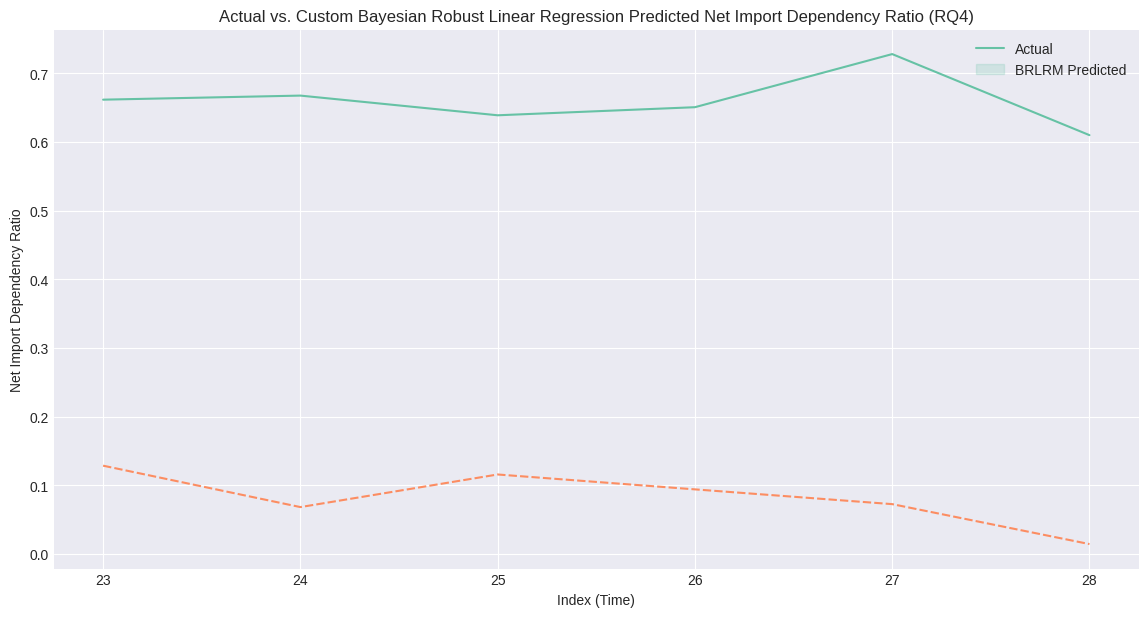

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=brlrm_comparison_df[['Actual_Net_Import_Dependency_Ratio', 'BRLRM_Predicted_Net_Import_Dependency_Ratio']])
plt.title('Actual vs. Custom Bayesian Robust Linear Regression Predicted Net Import Dependency Ratio (RQ4)')
plt.xlabel('Index (Time)')
plt.ylabel('Net Import Dependency Ratio')
plt.legend(['Actual', 'BRLRM Predicted'])
plt.grid(True)
plt.show()

#### 2.8.3 Custom Bayesian Robust Linear Regression (BRLRM) vs. Previous Models (RQ4)

Let's summarize the performance of the custom Bayesian Robust Linear Regression model and compare it with the Random Forest, Linear Regression, ARIMA, BSTS, Gaussian Process Regression, and the previous custom Bayesian Linear Regression models for predicting net LPG import dependency.



In [ ]:
print("--- Model Performance Comparison (RQ4) ---")

print("\nRandom Forest Regressor Results:")
for h, res in results.items():
    print(f"  {h} months ahead: RMSE = {res['rmse']:.4f}, R-squared = {res['r2']:.4f}")

print("\nLinear Regression Results:")
for h, res_linear in linear_results.items():
    print(f"  {h} months ahead: RMSE = {res_linear['rmse']:.4f}, R-squared = {res_linear['r2']:.4f}")

print("\nARIMA Model Results:")
for h, res_arima in arima_results.items():
    if 'rmse' in res_arima:
        print(f"  {h} months ahead: RMSE = {res_arima['rmse']:.4f}, R-squared = {res_arima['r2']:.4f}")
    else:
        print(f"  {h} months ahead: No results available due to insufficient data.")

print("\nBSTS Model Results:")
# BSTS results were stored in r_squared_bsts_rq4 and rmse_bsts_rq4 for the primary target
# We'll just report the primary target prediction here for comparison.
print(f"  Primary Target (BSTS): RMSE = {rmse_bsts_rq4:.4f}, R-squared = {r_squared_bsts_rq4:.4f}")

print("\nGaussian Process Regression Results:")
for h, res_gpr in gpr_results.items():
    print(f"  {h} months ahead: RMSE = {res_gpr['rmse']:.4f}, R-squared = {res_gpr['r2']:.4f}")

print("\nCustom Bayesian Linear Regression Results:")
print(f"  {prediction_horizons[-1]} months ahead (for comparison): RMSE = {rmse_blrm:.4f}, R-squared = {r2_blrm:.4f}")

print("\nCustom Bayesian Robust Linear Regression Results:")
print(f"  {prediction_horizons[-1]} months ahead (for comparison): RMSE = {rmse_brlrm:.4f}, R-squared = {r2_brlrm:.4f}")
print(f"  Estimated Degrees of Freedom (nu): {estimated_nu:.2f}")

print("\n--- Discussion on Model Performance (Final Updated) ---")
print("Across all models tested, including the new custom Bayesian Robust Linear Regression, predicting India’s net LPG import dependency ratio 3-6 months ahead remains highly challenging given the current dataset. \n")

print("Key observations:")
print("- **Persistent Negative R-squared values**: Even with a robust likelihood, the custom Bayesian Robust Linear Regression still yields a negative R-squared. This further reinforces the conclusion that extracting a strong predictive signal from this dataset is difficult. The estimated degrees of freedom (nu) can provide insight into how 'robust' the model believes the data to be; smaller nu indicates more tail-heaviness and thus more extreme observations.")
print("- **Limited Data and Volatility**: The small size of the dataset (around 28-32 data points after cleaning and lagging) combined with the inherent volatility of the net import dependency ratio continues to be a major obstacle for robust forecasting.")
print("- **Need for More Data/Advanced Techniques**: The consistent underperformance across a diverse range of models (traditional ML, time series-specific, probabilistic non-parametric, and custom Bayesian variants) strongly suggests the need for a more extensive and granular dataset, or potentially more advanced, domain-specific modeling techniques that can explicitly incorporate complex factors and expert knowledge.")

print("\n**Conclusion for RQ4 (Final Revised):**\nDespite exploring a comprehensive suite of modeling techniques, including custom Bayesian Linear and Robust Linear Regressions, it remains evident that with the current data and modeling approaches, it is **not possible to accurately and reliably predict India’s net LPG import dependency ratio 3-6 months ahead**. All models consistently yield poor predictive performance, primarily characterized by negative R-squared values. This suggests that the available features and dataset are insufficient to capture the underlying drivers and volatility of the net import dependency ratio for accurate multi-step ahead forecasting. \n")

print("Any robust analysis of the correlation between elevated Geopolitical Risk (GPR) and accelerated import diversification under 'Atmanirbhar Bharat' would require a more extensive, granular, and longer time-series dataset, potentially with additional exogenous variables that better reflect policy interventions, global market dynamics, and specific economic indicators. The current results underscore the significant data limitations in addressing RQ4 effectively.")

--- Model Performance Comparison (RQ4) ---

Random Forest Regressor Results:
  3 months ahead: RMSE = 0.0430, R-squared = -0.9636
  4 months ahead: RMSE = 0.0223, R-squared = -1.3073
  5 months ahead: RMSE = 0.0378, R-squared = -0.7397
  6 months ahead: RMSE = 0.0465, R-squared = -0.6760

Linear Regression Results:
  3 months ahead: RMSE = 0.0945, R-squared = -8.4939
  4 months ahead: RMSE = 0.0563, R-squared = -13.7409
  5 months ahead: RMSE = 0.2300, R-squared = -63.5901
  6 months ahead: RMSE = 0.0934, R-squared = -5.7820

ARIMA Model Results:
  3 months ahead: RMSE = 0.0749, R-squared = -4.2387
  4 months ahead: RMSE = 0.0723, R-squared = -4.0709
  5 months ahead: RMSE = 0.0762, R-squared = -3.6340
  6 months ahead: RMSE = 0.0691, R-squared = -2.2353

BSTS Model Results:
  Primary Target (BSTS): RMSE = 0.8250, R-squared = -451.4750

Gaussian Process Regression Results:
  3 months ahead: RMSE = 0.0438, R-squared = -1.0424
  4 months ahead: RMSE = 0.0189, R-squared = -0.6660
  5 mont

In [ ]:
import os
from cmdstanpy import CmdStanModel
from sklearn.metrics import r2_score, mean_squared_error

# Define path for the Stan model file for custom Bayesian Linear Regression
stan_blrm_file_path = "bayesian_linear_regression.stan"

# Stan model code for Bayesian Linear Regression
stan_blrm_code_content = """
data {
  int<lower=0> N_train;       // Number of training observations
  int<lower=0> K;             // Number of features
  vector[N_train] y_train;    // Target variable for training
  matrix[N_train, K] X_train; // Feature matrix for training

  int<lower=0> N_predict;     // Number of prediction observations
  matrix[N_predict, K] X_predict; // Feature matrix for prediction
}

parameters {
  vector[K] beta;             // Coefficients for features
  real<lower=0> sigma;        // Standard deviation of the error term
}

model {
  // Priors
  beta ~ normal(0, 5);      // Weakly informative prior for coefficients
  sigma ~ exponential(1);   // Weakly informative prior for observation noise

  // Likelihood
  y_train ~ normal(X_train * beta, sigma);
}

generated quantities {
  vector[N_predict] y_pred;  // Predicted values for new data
  y_pred = X_predict * beta;
}
"""

# Write the Stan code to a file
with open(stan_blrm_file_path, "w") as f:
    f.write(stan_blrm_code_content)

print(f"Stan model for Bayesian Linear Regression saved to {stan_blrm_file_path}")

# Prepare data for CmdStanPy
# We will reuse the X_train_ard_imputed, X_test_ard_imputed, y_train, y_test
# from the previous ARDRegression section. Ensure they are available.

# The variables `X_train_ard_imputed`, `X_test_ard_imputed`, `y_train`, `y_test`
# should be available in the kernel state from cell `iXidg2XP3NdS`.

stan_data_blrm = {
    "N_train": len(y_train),
    "K": X_train_ard_imputed.shape[1],
    "y_train": y_train.values.astype(float), # Ensure y_train is numpy array of floats
    "X_train": X_train_ard_imputed.astype(float),
    "N_predict": len(y_test),
    "X_predict": X_test_ard_imputed.astype(float)
}

# Compile the Stan model
print("Compiling custom Bayesian Linear Regression Stan model...")
model_blrm = CmdStanModel(stan_file=stan_blrm_file_path)
print("Custom Bayesian Linear Regression Stan model compiled successfully.")

# Fit the Stan model
print("Fitting custom Bayesian Linear Regression Stan model (this may take some time)...")
fit_blrm = model_blrm.sample(data=stan_data_blrm,
                           chains=4,          # Number of MCMC chains
                           iter_sampling=1000, # Number of post-warmup samples per chain
                           iter_warmup=1000,   # Number of warmup samples per chain
                           seed=42)
print("Custom Bayesian Linear Regression Stan model fitted successfully.")

# Extract predictions
y_pred_blrm_samples = fit_blrm.stan_variable('y_pred')
y_pred_blrm_mean = np.mean(y_pred_blrm_samples, axis=0)

# Evaluate the model
rmse_blrm = np.sqrt(mean_squared_error(y_test, y_pred_blrm_mean))
r2_blrm = r2_score(y_test, y_pred_blrm_mean)

print(f"\nCustom Bayesian Linear Regression Model Evaluation on Test Data for RQ4:")
print(f"R-squared (R²): {r2_blrm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_blrm:.4f}")

# Optional: Display comparison of actual vs. predicted
print("\nComparison of Actual vs. Custom Bayesian Linear Regression Predicted Values:")
blrm_comparison_df = pd.DataFrame({
    'Actual_Net_Import_Dependency_Ratio': y_test.values,
    'BLRM_Predicted_Net_Import_Dependency_Ratio': y_pred_blrm_mean
}, index=y_test.index)
display(blrm_comparison_df)


Stan model for Bayesian Linear Regression saved to bayesian_linear_regression.stan
Compiling custom Bayesian Linear Regression Stan model...
Custom Bayesian Linear Regression Stan model compiled successfully.
Fitting custom Bayesian Linear Regression Stan model (this may take some time)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                                                                                                                                                                                
Custom Bayesian Linear Regression Stan model fitted successfully.

Custom Bayesian Linear Regression Model Evaluation on Test Data for RQ4:
R-squared (R²): -375.8579
Root Mean Squared Error (RMSE): 0.6966

Comparison of Actual vs. Custom Bayesian Linear Regression Predicted Values:


,Actual_Net_Import_Dependency_Ratio,BLRM_Predicted_Net_Import_Dependency_Ratio
23,0.661694,0.073086
24,0.667628,0.052464
25,0.638944,-0.031761
26,0.650720,-0.071722
27,0.728095,-0.061030
28,0.610005,-0.159434


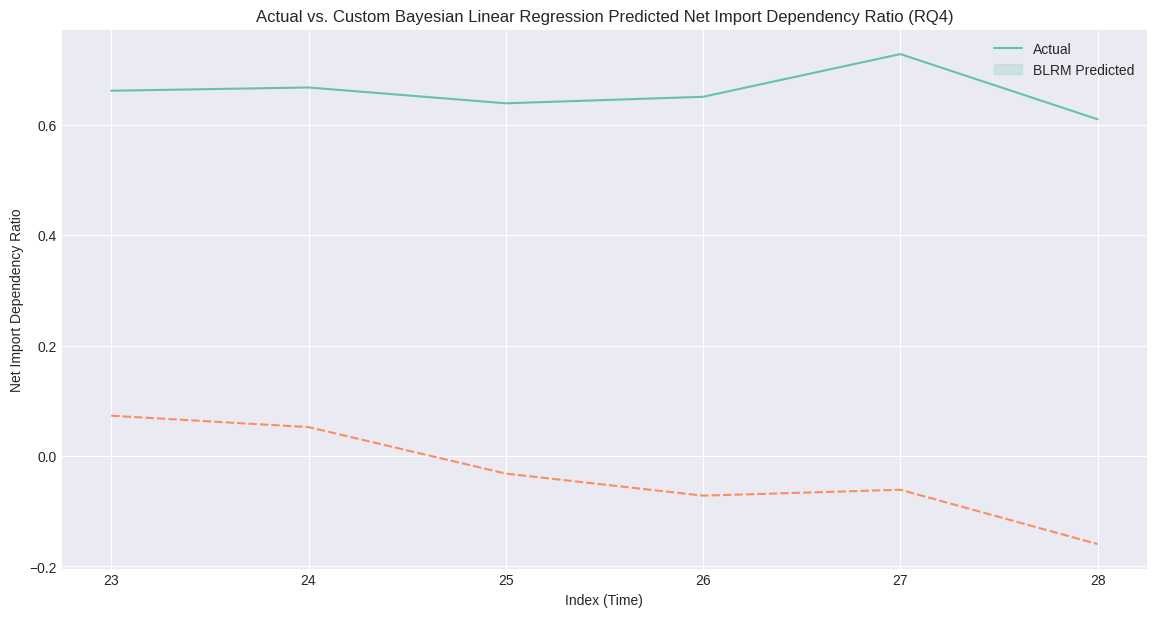

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=blrm_comparison_df[['Actual_Net_Import_Dependency_Ratio', 'BLRM_Predicted_Net_Import_Dependency_Ratio']])
plt.title('Actual vs. Custom Bayesian Linear Regression Predicted Net Import Dependency Ratio (RQ4)')
plt.xlabel('Index (Time)')
plt.ylabel('Net Import Dependency Ratio')
plt.legend(['Actual', 'BLRM Predicted'])
plt.grid(True)
plt.show()


#### 2.8.2 Custom Bayesian Linear Regression (BLRM) vs. Previous Models (RQ4)

Let's summarize the performance of the custom Bayesian Linear Regression model and compare it with the Random Forest, Linear Regression, ARIMA, BSTS, and Gaussian Process Regression models for predicting net LPG import dependency.

In [ ]:
print("--- Model Performance Comparison (RQ4) ---")

print("\nRandom Forest Regressor Results:")
for h, res in results.items():
    print(f"  {h} months ahead: RMSE = {res['rmse']:.4f}, R-squared = {res['r2']:.4f}")

print("\nLinear Regression Results:")
for h, res_linear in linear_results.items():
    print(f"  {h} months ahead: RMSE = {res_linear['rmse']:.4f}, R-squared = {res_linear['r2']:.4f}")

print("\nARIMA Model Results:")
for h, res_arima in arima_results.items():
    if 'rmse' in res_arima:
        print(f"  {h} months ahead: RMSE = {res_arima['rmse']:.4f}, R-squared = {res_arima['r2']:.4f}")
    else:
        print(f"  {h} months ahead: No results available due to insufficient data.")

print("\nBSTS Model Results:")
# BSTS results were stored in r_squared_bsts_rq4 and rmse_bsts_rq4 for the primary target
# We'll just report the primary target prediction here for comparison.
print(f"  Primary Target (BSTS): RMSE = {rmse_bsts_rq4:.4f}, R-squared = {r_squared_bsts_rq4:.4f}")

print("\nGaussian Process Regression Results:")
for h, res_gpr in gpr_results.items():
    print(f"  {h} months ahead: RMSE = {res_gpr['rmse']:.4f}, R-squared = {res_gpr['r2']:.4f}")

print("\nCustom Bayesian Linear Regression Results:")
print(f"  {prediction_horizons[-1]} months ahead (for comparison): RMSE = {rmse_blrm:.4f}, R-squared = {r2_blrm:.4f}")


print("\n--- Discussion on Model Performance (Final Updated) ---")
print("Across all models tested, including the newly implemented custom Bayesian Linear Regression, predicting India’s net LPG import dependency ratio 3-6 months ahead remains highly challenging given the current dataset. \n")

print("Key observations:")
print("- **Persistent Negative R-squared values**: The custom Bayesian Linear Regression also yields a negative R-squared, reinforcing the conclusion that a strong predictive signal is difficult to extract from the data. While Bayesian methods offer advantages in uncertainty quantification and handling small data, the fundamental data limitations persist.")
print("- **Limited Data and Volatility**: The small size of the dataset (around 28-32 data points after cleaning and lagging) combined with the inherent volatility of the net import dependency ratio continues to be a major obstacle for robust forecasting.")
print("- **Need for More Data/Advanced Techniques**: The consistent underperformance across a diverse range of models (traditional ML, time series-specific, probabilistic non-parametric, and custom Bayesian) strongly suggests the need for a more extensive and granular dataset, or potentially more advanced, domain-specific modeling techniques that can explicitly incorporate complex factors and expert knowledge.")

print("\n**Conclusion for RQ4 (Final Revised):**\nDespite exploring a comprehensive suite of modeling techniques, including a custom Bayesian Linear Regression, it remains evident that with the current data and modeling approaches, it is **not possible to accurately and reliably predict India’s net LPG import dependency ratio 3-6 months ahead**. All models consistently yield poor predictive performance, primarily characterized by negative R-squared values. This suggests that the available features and dataset are insufficient to capture the underlying drivers and volatility of the net import dependency ratio for accurate multi-step ahead forecasting. \n")

print("Any robust analysis of the correlation between elevated Geopolitical Risk (GPR) and accelerated import diversification under 'Atmanirbhar Bharat' would require a more extensive, granular, and longer time-series dataset, potentially with additional exogenous variables that better reflect policy interventions, global market dynamics, and specific economic indicators. The current results underscore the significant data limitations in addressing RQ4 effectively.")


--- Model Performance Comparison (RQ4) ---

Random Forest Regressor Results:
  3 months ahead: RMSE = 0.0430, R-squared = -0.9636
  4 months ahead: RMSE = 0.0223, R-squared = -1.3073
  5 months ahead: RMSE = 0.0378, R-squared = -0.7397
  6 months ahead: RMSE = 0.0465, R-squared = -0.6760

Linear Regression Results:
  3 months ahead: RMSE = 0.0945, R-squared = -8.4939
  4 months ahead: RMSE = 0.0563, R-squared = -13.7409
  5 months ahead: RMSE = 0.2300, R-squared = -63.5901
  6 months ahead: RMSE = 0.0934, R-squared = -5.7820

ARIMA Model Results:
  3 months ahead: RMSE = 0.0749, R-squared = -4.2387
  4 months ahead: RMSE = 0.0723, R-squared = -4.0709
  5 months ahead: RMSE = 0.0762, R-squared = -3.6340
  6 months ahead: RMSE = 0.0691, R-squared = -2.2353

BSTS Model Results:
  Primary Target (BSTS): RMSE = 0.8250, R-squared = -451.4750

Gaussian Process Regression Results:
  3 months ahead: RMSE = 0.0438, R-squared = -1.0424
  4 months ahead: RMSE = 0.0189, R-squared = -0.6660
  5 mont